In [135]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from scipy.stats import expon
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
from copulas.multivariate import GaussianMultivariate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings
import numpy as np
import umap

### column differentiation:

In [203]:
#nomi delle colonne da generare
columns_to_generate = [
    'Durata','CabEnabled_M1', 'CabEnabled_M8', 'ERTMS_PiastraSts', 'HMI_ACPntSts_T2', 'HMI_ACPntSts_T7', 'HMI_DCPntSts_T2',
    'HMI_DCPntSts_T7', 'HMI_Iline', 'HMI_Irsts_T2', 'HMI_Irsts_T7', 'HMI_VBatt_T2', 'HMI_VBatt_T4', 'HMI_VBatt_T5',
    'HMI_VBatt_T7', 'HMI_Vline', 'HMI_impSIL', 'LineVoltType', 'MDS_LedLimVel', 'MDS_StatoMarcia', '_GPS_LAT',
    '_GPS_LON', 'ldvvelimps', 'ldvveltreno', 'usB1BCilPres_M1', 'usB1BCilPres_M3', 'usB1BCilPres_M6', 'usB1BCilPres_M8',
    'usB1BCilPres_T2', 'usB1BCilPres_T4', 'usB1BCilPres_T5', 'usB1BCilPres_T7', 'usB2BCilPres_M1', 'usB2BCilPres_M3',
    'usB2BCilPres_M6', 'usB2BCilPres_M8', 'usB2BCilPres_T2', 'usB2BCilPres_T4', 'usB2BCilPres_T5', 'usB2BCilPres_T7',
    'usBpPres', 'usMpPres'
]

non_numeric_cols = [
        'Descrizione',
        'Timestamp chiusura',
        'Posizione',
        'Flotta',
        'Veicolo',
        'Codice',
        'Nome',
        'Test',
        'Sistema',
        'Componente',
        'Timestamp segnale']

### reading the csv:

In [257]:
dataset = pd.read_csv('dataset.csv')
dataset_new = dataset.copy()
dataset_new['Timestamp'] = pd.to_datetime(dataset_new['Timestamp'], errors='coerce')
# timestamp will be essential
dataset_new = dataset_new.dropna(subset=['Timestamp', 'Timestamp chiusura'])
# repeated signals:
dataset_new = dataset_new.drop_duplicates(subset=['Descrizione', 'Timestamp'])


### some observations:

# concurrent signals (clock granularity)
print('"freq" is the number of different events arriving at a same timestamp.')
dataset_new.groupby('Timestamp')['Flotta'].describe().groupby('freq').count()['count']

In [258]:
print("types of non numeric columns")
dataset_new[non_numeric_cols].nunique()

types of non numeric columns


Descrizione             361
Timestamp chiusura    10320
Posizione                95
Flotta                    1
Veicolo                   1
Codice                  485
Nome                    263
Test                      1
Sistema                  16
Componente              160
Timestamp segnale      6781
dtype: int64

In [259]:
dataset_new['Sistema'].unique()

array(['HVAC', 'VEHICLE', 'AT', 'MDS', 'BANCO', 'FRENO', 'PORTE_INT',
       'TRAZIONE', 'LVOLT', 'PORTE_EST', 'SCMT', 'TOILETTE', 'CARRELLI',
       'TCMS', 'ANTINCENDIO', 'AUSILIARI'], dtype=object)

In [260]:
dataset_new['Componente'].unique()

array(['HVAC_CAB_M1', 'VEHICLE', 'T7_MCB', 'T7_PANTO', 'MDS', 'M1_4K14',
       'FRENO', 'T2_MCB', 'T2_PANTO', 'HVAC_M8', 'M3_Porta_gangway_2',
       'HVAC_T2', 'HVAC_T5', 'T2_1Q2_IR', 'CONV_TRAZ_M6', 'CONV_TRAZ_M1',
       'T2_1Q4_IP', 'TCU_M8', 'CONV_TRAZ_M8', 'CONV_TRAZ_M3', 'T7_1Q4_IP',
       'M1_9K42', 'M8_9K42', 'M3_Gradino_Porta4', 'SCMT_M1', 'T7_1Q2_IR',
       'HVAC_T4', 'BCU_M1', 'HVAC_M6', 'HVAC_CAB_M8',
       'M1_Porta_gangway_1', 'SCMT_M8', 'TOIL_T7', 'M6_Porta_gangway_2',
       'T5_Porta_gangway_1', 'T5_Porta_gangway_2', 'T7_Porta_gangway_2',
       'M6_Porta_gangway_1', 'TCU_M3', 'T2_1Q7', 'AT',
       'T2_Porta_gangway_2', 'M8_Porta_gangway_1', 'T7_Porta_gangway_1',
       'T4_Porta_gangway_1', 'EDCU_M6_3', 'HVAC_M3', 'HVAC_T7',
       'M6_Gradino_Porta1', 'EDCU_T4_2', 'EDCU_T2_1', 'CARRELLI',
       'Ungibordo_M8', 'HUNTING_T2', 'T4_Porta_gangway_2', 'EDCU_M3_1',
       'M6_Gradino_Porta2', 'EDCU_M3_3', 'EDCU_M6_4', 'BCU_M8',
       'M1_Gradino_Porta2', 'TOIL_T5', 

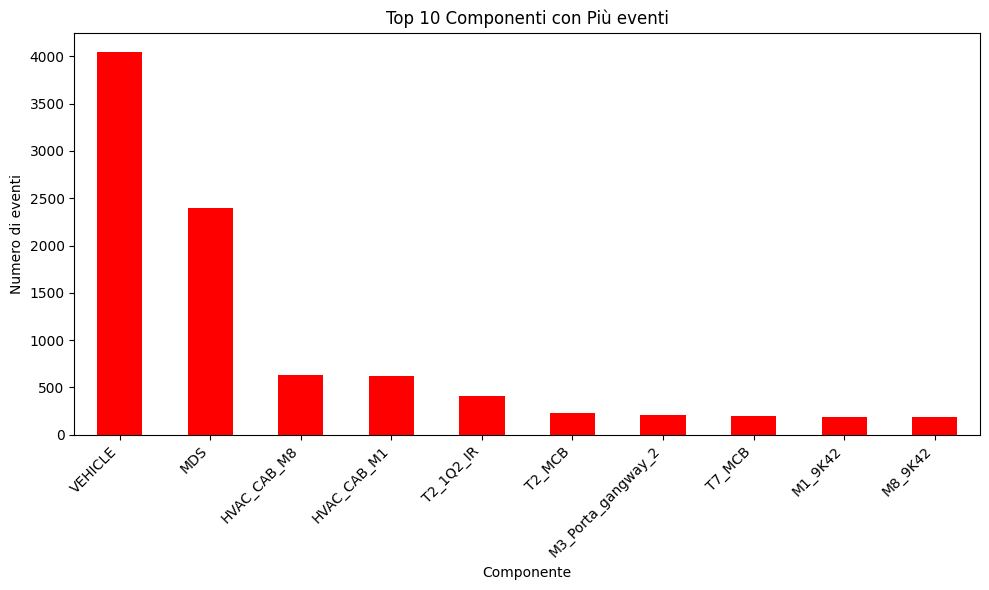

In [261]:
# popular "componente"
eventi_per_sistema = dataset_new.groupby(['Componente']).count()['Flotta']

top_events = eventi_per_sistema.nlargest(10)
plt.figure(figsize=(10, 6))
top_events.plot(kind='bar', color='red')
plt.title('Top 10 Componenti con Più eventi')
plt.xlabel('Componente')
plt.ylabel('Numero di eventi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



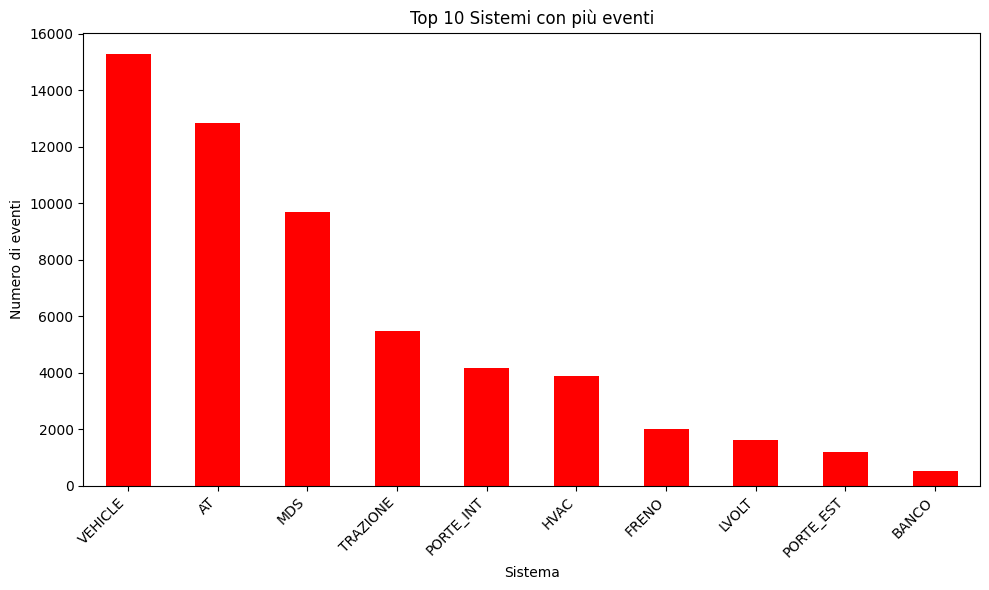

In [262]:
# popular "sistema"
eventi_per_sistema = dataset.groupby(['Sistema']).count()['Flotta']

top_events = eventi_per_sistema.nlargest(10)
plt.figure(figsize=(10, 6))
top_events.plot(kind='bar', color='red')
plt.title('Top 10 Sistemi con più eventi')
plt.xlabel('Sistema')
plt.ylabel('Numero di eventi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



### filtering

In [264]:
#filtro il dataset per il componente VEHICLE e rimuovo le colonne vuote
print(f"Numero di righe prima del filtraggio: {dataset.shape[0]}")
print(f"Numero di colonne prima della rimozione di colonne vuote: {dataset.shape[1]}")
dataset_new = dataset_new[dataset_new['Componente'] == 'VEHICLE']
dataset_new = dataset_new.dropna(axis=1, how='all')
dataset_new = dataset_new.dropna()
dataset_new.set_index('Timestamp', inplace=True)
print(f"Numero di righe dopo il filtraggio: {dataset_new.shape[0]}")
print(f"Numero di colonne dopo la rimozione di colonne vuote: {dataset_new.shape[1]}")

Numero di righe prima del filtraggio: 57652
Numero di colonne prima della rimozione di colonne vuote: 169
Numero di righe dopo il filtraggio: 3987
Numero di colonne dopo la rimozione di colonne vuote: 56


### More observations:

In [265]:
dataset_new[non_numeric_cols].nunique()

Descrizione             40
Timestamp chiusura    3623
Posizione               70
Flotta                   1
Veicolo                  1
Codice                  40
Nome                    32
Test                     1
Sistema                  1
Componente               1
Timestamp segnale     2765
dtype: int64

In [266]:
dataset_new.groupby(['Codice','Nome','Descrizione'])['Flotta'].count()

Codice        Nome               Descrizione                                            
011200        CCU_FltWtbR1       Mancata ricezione R1 in CCU M1                               29
011201        CCU_FltWtbR2       Mancata ricezione R2 in CCU M1                               32
011202        CCU_FltWtbComm     Mancata comunicazione WTB in CCU M1                          61
011203        CCU_GtwFlt         Guasto GTW semitreno M1-T4                                    1
018200        CCU_FltWtbR1       Mancata ricezione R1 in CCU M8                               23
018201        CCU_FltWtbR2       Mancata ricezione R2 in CCU M8                               34
018202        CCU_FltWtbComm     Mancata comunicazione WTB in CCU M8                          56
020006        _NokVoltSts_       Incoerenza Tensione di Linea                                  1
150004        _LineVoltType_     Selezionata tensione 3 kV                                     9
150005        _LineVoltType_     Selez

In [267]:
dataset_new.groupby(['Posizione'])['Flotta'].count()

Posizione
Botticino       21
Brendola        15
Brescia        121
Bussolengo       2
Calcinato       19
              ... 
Varmo            3
Venezia       1243
Verona         143
Vicenza        147
Vimodrone       21
Name: Flotta, Length: 70, dtype: int64

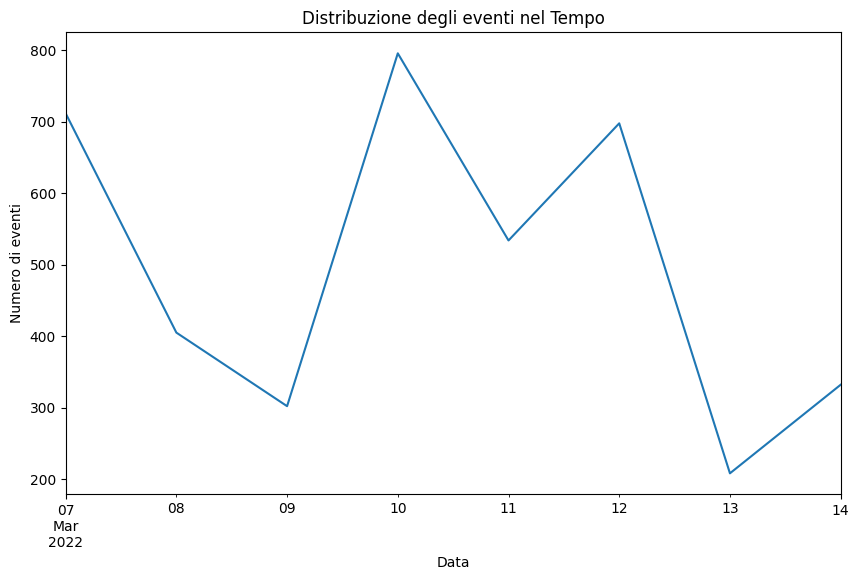

In [268]:
#visualizzazione della distribazione degli eventi nel tempo
dataset_new.resample('D').size().plot(title='Distribuzione degli eventi nel Tempo', figsize=(10, 6))
plt.xlabel('Data')
plt.ylabel('Numero di eventi')
plt.show()

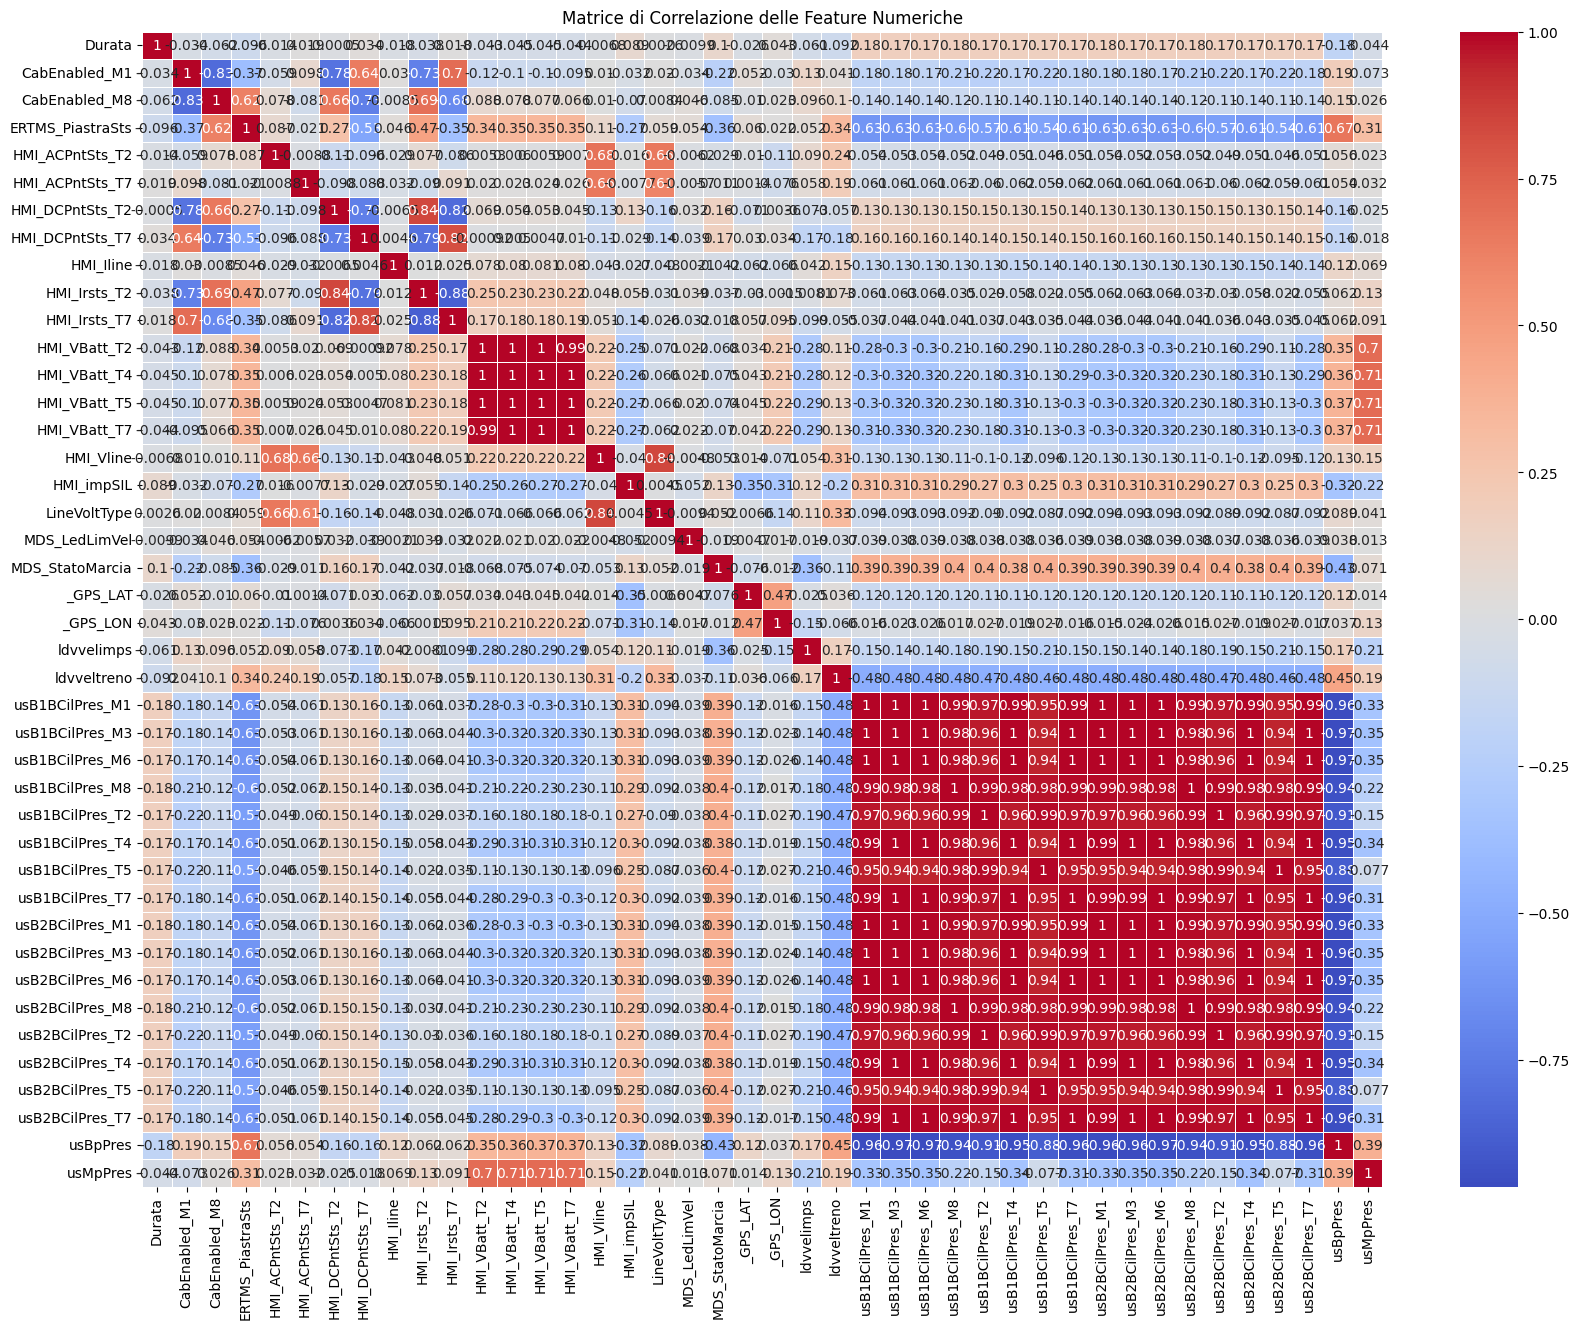

In [269]:
#matrice di correlazione
correlation_matrix = dataset_new[columns_to_generate].corr()
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matrice di Correlazione delle Feature Numeriche')
plt.show()

### Yet more filtering:

In [283]:
print("==========Eventi più popolari:==========")
print(dataset_new.groupby('Descrizione').count()['Flotta'].nlargest(10))
popular_descriptions = dataset_new.groupby('Descrizione')['Flotta'].count().nlargest(10).index
dataset_new = dataset_new[dataset_new['Descrizione'].isin(popular_descriptions)]
print("\n\n","="*50)
print('Il dataset con i 10 eventi più gettonati è lungo ',len(dataset_new), 'record')
print("="*50)
description_map = {desc: i for i, desc in enumerate(popular_descriptions)}
descrizioni_numeriche = dataset_new['Descrizione'].map(description_map)

print("\n\n\n==========Posizioni più popolari:==========")
print(dataset_new.groupby('Posizione')['Flotta'].count().nlargest(10))
populat_positions = dataset_new.groupby('Posizione')['Flotta'].count().nlargest(10).index
dataset_new = dataset_new[dataset_new['Posizione'].isin(populat_positions)]
print("="*50)
print('il dataset con i 10 eventi più gettonati è le 10 posizioni più gettonate e lungo ',len(dataset_new), 'record')
print("="*50)
position_map = {desc: i for i, desc in enumerate(populat_positions)}
posizioni_numeriche = dataset_new['Posizione'].map(position_map)

==========Eventi più popolari:==========
Descrizione
Cod. 03 Comando di frenatura da manipolatore attivo        1156
Cod. 04 Condotta Generale scarica                           502
Pressione CP sotto 8.5 bar in M8 (press. 9S14)              173
Cod. 05 Taglio trazione da SSB attivo                       171
Cod. 08 Loop porte aperto                                   168
Stato STANDBY attivo                                         73
Cod. 01 Max fren. di servizio richiesta da segnalamento      71
Stato RUNNING attivo                                         65
Mancata comunicazione WTB in CCU M1                          61
Cod. 10 Nessuna velocita' impostata                          59
Name: Flotta, dtype: int64


Il dataset con i 10 eventi più gettonati è lungo  2499 record



==========Posizioni più popolari:==========
Posizione
Venezia                 907
Milano                  665
Trieste                 200
Vicenza                 144
Verona                  139
Brescia            

### Visualisations:

In [284]:
X = dataset_new[columns_to_generate].values
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
# Fit and transform the data
embedding = reducer.fit_transform(X.reshape(X.shape[0], -1))

/home/chucho/Projects/Realistic_TCMS_simulation/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


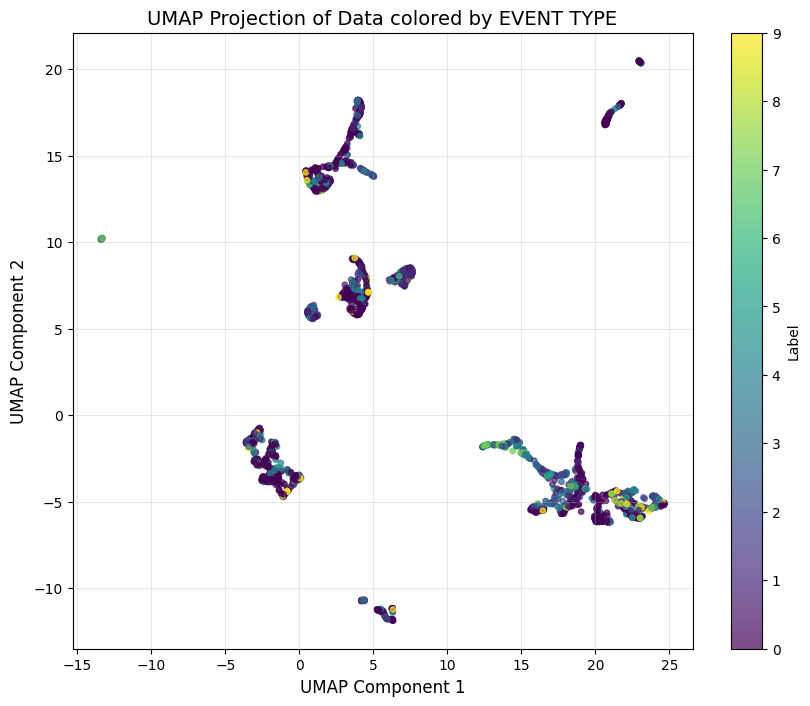

In [285]:
# Visualize the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=descrizioni_numeriche, s=15, alpha=0.7)
plt.title('UMAP Projection of Data colored by EVENT TYPE', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()

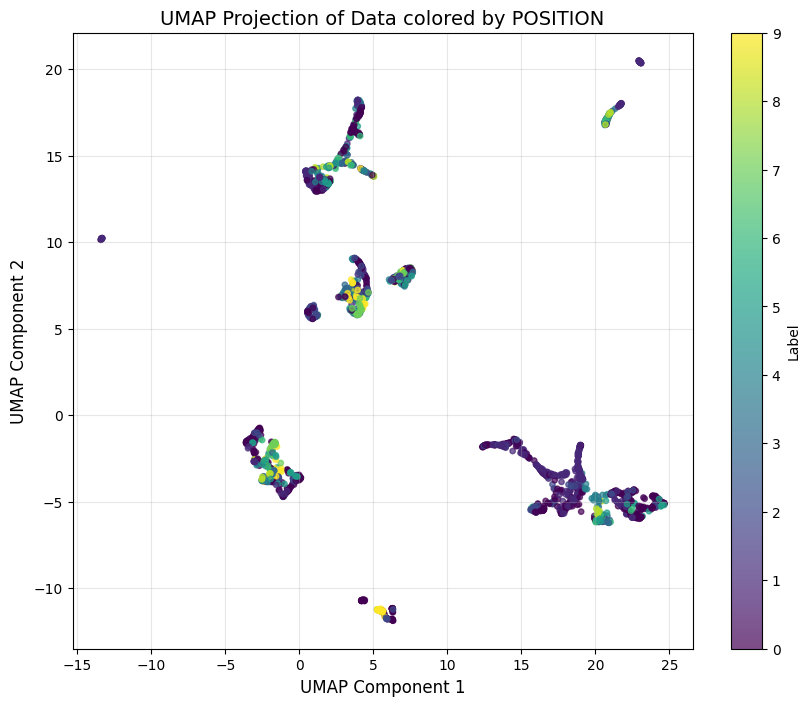

In [286]:
# Visualize the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=posizioni_numeriche, s=15, alpha=0.7)
plt.title('UMAP Projection of Data colored by POSITION', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
dataset_new.sort_values(by='Timestamp', inplace=True)

/tmp/ipykernel_109255/1710657337.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vehicle_largest_descriptions.sort_values(by='Timestamp', inplace=True)


In [ ]:
dataset_new.groupby('Timestamp')['Flotta'].describe().groupby('freq').count()

,count,unique,top
freq,,,
1,2817,2817,2817
2,139,139,139
3,20,20,20
4,3,3,3
5,9,9,9


In [16]:
#calcolo il tempo di interarrivo medio tra le anomalie
anomalies = vehicle_data_clean[vehicle_data_clean['Tipo_Evento'] == 'Anomalia']

anomalies_sorted = anomalies.sort_values(by='Timestamp')

anomalies_sorted['Interarrival_Time'] = anomalies_sorted['Timestamp'].diff().dt.total_seconds()

anomalies_interarrival = anomalies_sorted['Interarrival_Time'].dropna()

print(f"Numero di anomalie dopo il calcolo del tempo di interarrivo: {len(anomalies_interarrival)}")

Numero di anomalie dopo il calcolo del tempo di interarrivo: 1811


In [17]:
#filtro le anomalie per la deviazione standard
mean_anomalies = anomalies_interarrival.mean()

std_anomalies = anomalies_interarrival.std()

filtered_anomalies_interarrival = anomalies_interarrival[
    (anomalies_interarrival > mean_anomalies - 2 * std_anomalies) &
    (anomalies_interarrival < mean_anomalies + 2 * std_anomalies)
]

print(f"Numero di anomalie dopo il filtraggio: {len(filtered_anomalies_interarrival)}")

Numero di anomalie dopo il filtraggio: 1790


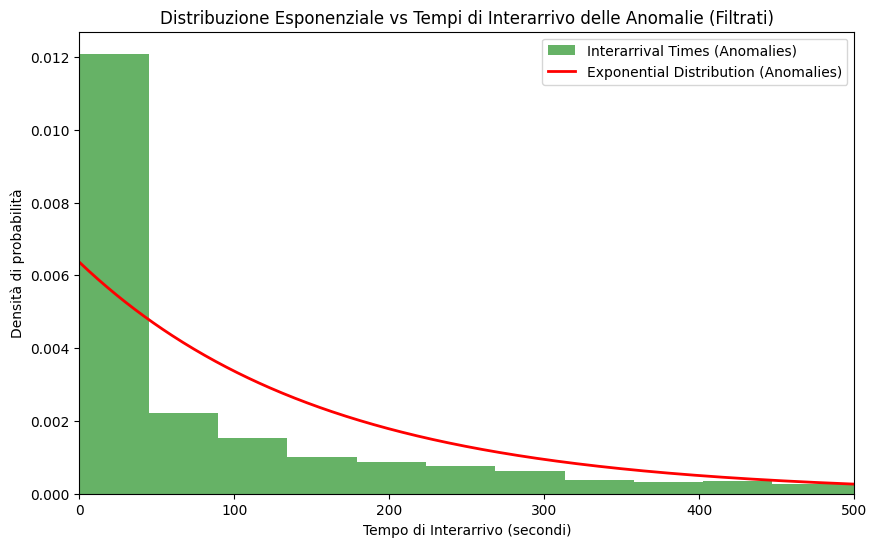

In [18]:
#distribuzione esponenziale sui tempi di interarrivo delle anomalie, filtrato per deviazione standard maggiore di 2
lambda_expon_anomalies = 1 / filtered_anomalies_interarrival.mean()
x_limit = 500
expon_distribution_anomalies = expon.pdf(range(x_limit), scale=1/lambda_expon_anomalies)

plt.figure(figsize=(10,6))
plt.hist(filtered_anomalies_interarrival, bins=100, density=True, alpha=0.6, color='g', label='Interarrival Times (Anomalies)')
plt.plot(range(x_limit), expon_distribution_anomalies, 'r-', lw=2, label='Exponential Distribution (Anomalies)')
plt.title('Distribuzione Esponenziale vs Tempi di Interarrivo delle Anomalie (Filtrati)')
plt.xlabel('Tempo di Interarrivo (secondi)')
plt.ylabel('Densità di probabilità')
plt.xlim(0, x_limit)
plt.legend()
plt.show()

In [19]:
#calcolo il tempo di interarrivo medio tra i funzionamenti normali
normal_operations = vehicle_data_clean[vehicle_data_clean['Tipo_Evento'] == 'Funzionamento Normale']

normal_operations_sorted = normal_operations.sort_values(by='Timestamp')

normal_operations_sorted['Interarrival_Time'] = normal_operations_sorted['Timestamp'].diff().dt.total_seconds()

normal_interarrival = normal_operations_sorted['Interarrival_Time'].dropna()

print(f"Numero di operazioni normali dopo il calcolo del tempo di interarrivo: {len(normal_interarrival)}")

Numero di operazioni normali dopo il calcolo del tempo di interarrivo: 2197


In [20]:
#filtro i log di funzionamento nornmale per la deviazione standard
mean_normal = normal_interarrival.mean()

std_normal = normal_interarrival.std()

filtered_normal_interarrival = normal_interarrival[
    (normal_interarrival > mean_normal - 2 * std_normal) &
    (normal_interarrival < mean_normal + 2 * std_normal)
]

print(f"Numero di operazioni normali dopo il filtraggio: {len(filtered_normal_interarrival)}")

Numero di operazioni normali dopo il filtraggio: 2172


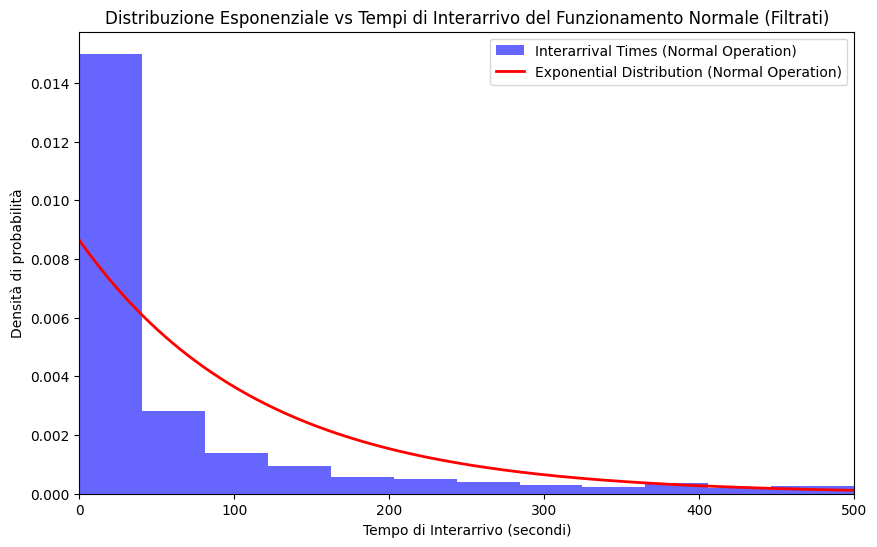

In [21]:
#distribuzione esponenziale sui tempi di interarrivo del funzionamento normale, filtrato per deviazione standard maggiore di 2
lambda_expon_normal = 1 / filtered_normal_interarrival.mean()
expon_distribution_normal = expon.pdf(range(x_limit), scale=1/lambda_expon_normal)

plt.figure(figsize=(10,6))
plt.hist(filtered_normal_interarrival, bins=100, density=True, alpha=0.6, color='b', label='Interarrival Times (Normal Operation)')
plt.plot(range(x_limit), expon_distribution_normal, 'r-', lw=2, label='Exponential Distribution (Normal Operation)')
plt.title('Distribuzione Esponenziale vs Tempi di Interarrivo del Funzionamento Normale (Filtrati)')
plt.xlabel('Tempo di Interarrivo (secondi)')
plt.ylabel('Densità di probabilità')
plt.xlim(0, x_limit)
plt.legend()
plt.show()

In [22]:
#calcolo media e mediana dei tempi di interarrivo delle anomalie e del funzionamento normale
mean_filtered_anomalies = filtered_anomalies_interarrival.mean()
median_filtered_anomalies = filtered_anomalies_interarrival.median()
print(f"Media dei tempi di interarrivo delle anomalie filtrate: {mean_filtered_anomalies}")
print(f"Mediana dei tempi di interarrivo delle anomalie filtrate: {median_filtered_anomalies}")

mean_filtered_normal = filtered_normal_interarrival.mean()
median_filtered_normal = filtered_normal_interarrival.median()
print(f"Media dei tempi di interarrivo del funzionamento normale filtrato: {mean_filtered_normal}")
print(f"Mediana dei tempi di interarrivo del funzionamento normale filtrato: {median_filtered_normal}")

Media dei tempi di interarrivo delle anomalie filtrate: 157.1141134078212
Mediana dei tempi di interarrivo delle anomalie filtrate: 30.200499999999998
Media dei tempi di interarrivo del funzionamento normale filtrato: 115.65564917127072
Mediana dei tempi di interarrivo del funzionamento normale filtrato: 22.298499999999997


In [23]:
#caricare il dataset e selezionare i dati
print(f"Dataset caricato con {len(df_cleaned_no_nan)} righe.")

df_anomalie = df_cleaned_no_nan[df_cleaned_no_nan['Tipo_Evento_Classificato'] == 0]
df_normali = df_cleaned_no_nan[df_cleaned_no_nan['Tipo_Evento_Classificato'] == 1]
print(f"Eventi di anomalia selezionati: {len(df_anomalie)} righe.")
print(f"Eventi di funzionamento normale selezionati: {len(df_normali)} righe.")

Dataset caricato con 14356 righe.
Eventi di anomalia selezionati: 7766 righe.
Eventi di funzionamento normale selezionati: 6590 righe.


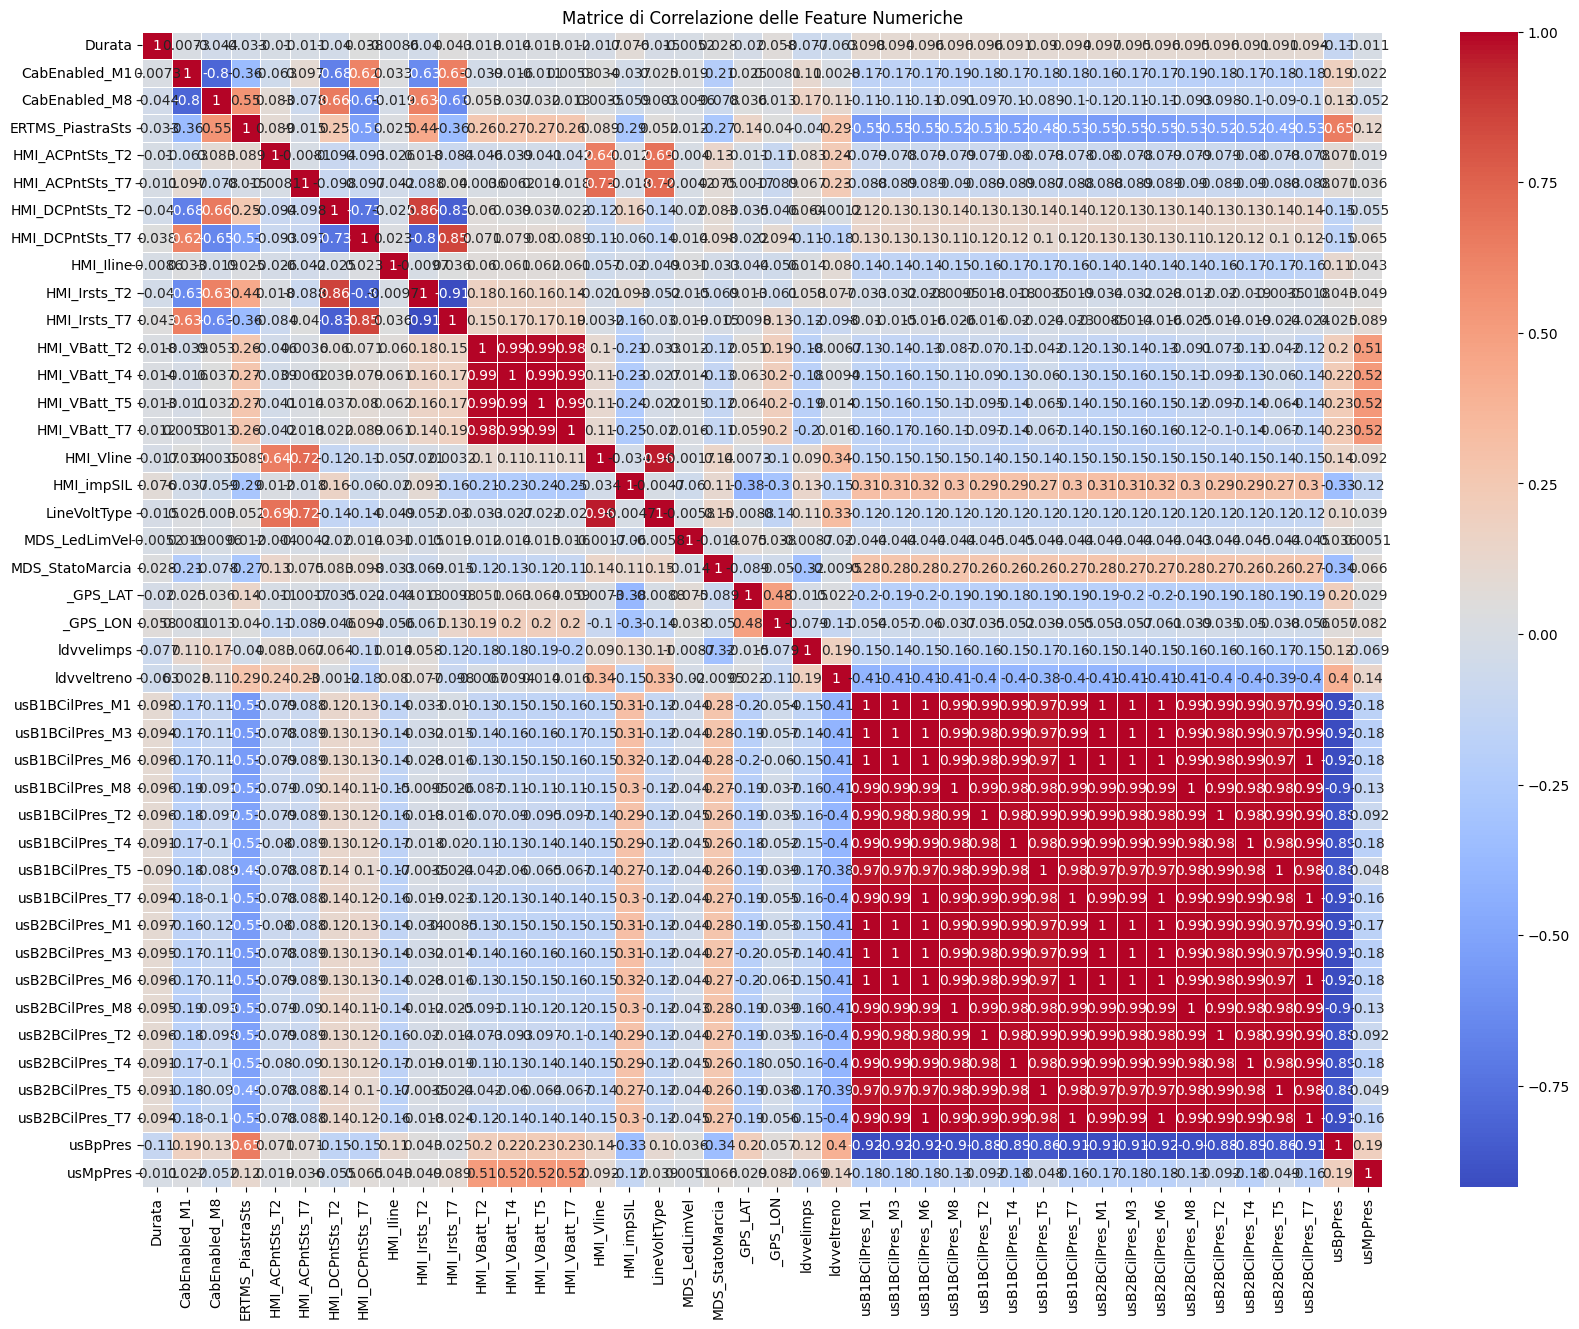

In [24]:
#matrice di correlazione
correlation_matrix = df_anomalie[columns_to_generate].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matrice di Correlazione delle Feature Numeriche')
plt.show()

In [ ]:
#creatzione modello e valutazione accuratezza
X = df_cleaned_no_nan.drop(columns=['Tipo_Evento_Classificato', 'Tipo_Evento', 'Descrizione', 'Timestamp', 'Timestamp chiusura', 'Posizione', 'Flotta', 'Veicolo', 'Codice', 'Nome', 'Test', 'Longitudine', 'Latitudine', 'Contemporaneo'])

y_final = df_cleaned_no_nan['Tipo_Evento_Classificato']

y_final = y_final.replace({1: 'Funzionamento Normale', 0: 'Anomalia'})

non_numeric_columns = X.select_dtypes(include=['object']).columns

X = X.drop(columns=non_numeric_columns)

X_train, X_test, y_train, y_test = train_test_split(X, y_final, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, target_names=['Anomalia', 'Funzionamento Normale'])

print(f"Accuratezza del modello: {accuracy:.4f}")
print("Report di classificazione:")
print(classification_rep)

Accuratezza del modello: 0.8653
Report di classificazione:
                       precision    recall  f1-score   support

             Anomalia       0.87      0.88      0.88      1569
Funzionamento Normale       0.86      0.84      0.85      1303

             accuracy                           0.87      2872
            macro avg       0.86      0.86      0.86      2872
         weighted avg       0.87      0.87      0.87      2872



In [26]:
#rimuovo i duplicati consecutivi
columns_to_check = ['Descrizione', 'Timestamp', 'Codice', 'Nome']

df_deduplicated_anomalies = df_anomalie.loc[(df_anomalie[columns_to_check] != df_anomalie[columns_to_check].shift()).any(axis=1)]

print(f"Righe originali: {len(df_anomalie)}")
print(f"Righe dopo rimozione delle ridondanze: {len(df_deduplicated_anomalies)}")


Righe originali: 7766
Righe dopo rimozione delle ridondanze: 1828


In [27]:
#rimuovo i duplicati consecutivi
columns_to_check = ['Descrizione', 'Timestamp', 'Codice', 'Nome']

df_deduplicated_normals = df_normali.loc[(df_normali[columns_to_check] != df_normali[columns_to_check].shift()).any(axis=1)]

print(f"Righe originali: {len(df_normali)}")
print(f"Righe dopo rimozione delle ridondanze: {len(df_deduplicated_normals)}")


Righe originali: 6590
Righe dopo rimozione delle ridondanze: 2198


In [28]:
#generazione dati sintetici con copula gaussiana
warnings.filterwarnings("ignore", category=RuntimeWarning)

data_us_anomalie = df_deduplicated_anomalies[columns_to_generate].drop(columns=['Durata'])
data_us_normali = df_deduplicated_normals[columns_to_generate].drop(columns=['Durata'])

copula_us_anomalie = GaussianMultivariate()
copula_us_anomalie.fit(data_us_anomalie)

copula_us_normali = GaussianMultivariate()
copula_us_normali.fit(data_us_normali)

synthetic_us_anomalie = copula_us_anomalie.sample(len(data_us_anomalie))
synthetic_us_normali = copula_us_normali.sample(len(data_us_normali))

alpha = 0.2
beta = 1.9

media_durata_anomalie = 157 * alpha
media_durata_normali = 115 * alpha

sigma_anomalie = 1 * beta
sigma_normali = 1 * beta

synthetic_us_anomalie['Durata'] = np.random.lognormal(mean=np.log(media_durata_anomalie), sigma=sigma_anomalie, size=len(synthetic_us_anomalie))
synthetic_us_normali['Durata'] = np.random.lognormal(mean=np.log(media_durata_normali), sigma=sigma_normali, size=len(synthetic_us_normali))

synthetic_us_anomalie['Tipo_Evento'] = "Anomalia"
synthetic_us_normali['Tipo_Evento'] = "Funzionamento Normale"

synthetic_us_anomalie['Tipo_Evento_Classificato'] = 0
synthetic_us_normali['Tipo_Evento_Classificato'] = 1

warnings.filterwarnings("default", category=RuntimeWarning)

In [29]:
#sposto colonna durata in prima posizione e salvo i dataset
col_durata_anomalie = synthetic_us_anomalie.pop('Durata')
synthetic_us_anomalie.insert(0, 'Durata', col_durata_anomalie)

col_durata_normali = synthetic_us_normali.pop('Durata')
synthetic_us_normali.insert(0, 'Durata', col_durata_normali)

synthetic_us_anomalie.to_csv('dataset_sintetico_anomalie.csv', index=False)
synthetic_us_normali.to_csv('dataset_sintetico_normali.csv', index=False)

In [30]:
#calcolo media e mediana dei tempi di interarrivo delle anomalie e del funzionamento normale
mean_filtered_synthetic_anomalies = synthetic_us_anomalie['Durata'].mean()
median_filtered_synthetic_anomalies = synthetic_us_anomalie['Durata'].median()
print(f"Media dei tempi di interarrivo delle anomalie filtrate: {mean_filtered_synthetic_anomalies}")
print(f"Mediana dei tempi di interarrivo delle anomalie filtrate: {median_filtered_synthetic_anomalies}")

mean_filtered_synthetic_normal = synthetic_us_normali['Durata'].mean()
median_filtered_synthetic_normal = synthetic_us_normali['Durata'].median()
print(f"Media dei tempi di interarrivo del funzionamento normale filtrato: {mean_filtered_synthetic_normal}")
print(f"Mediana dei tempi di interarrivo del funzionamento normale filtrato: {median_filtered_synthetic_normal}")

Media dei tempi di interarrivo delle anomalie filtrate: 193.3323759937634
Mediana dei tempi di interarrivo delle anomalie filtrate: 33.486727468352925
Media dei tempi di interarrivo del funzionamento normale filtrato: 123.97434237229005
Mediana dei tempi di interarrivo del funzionamento normale filtrato: 21.105620182085307


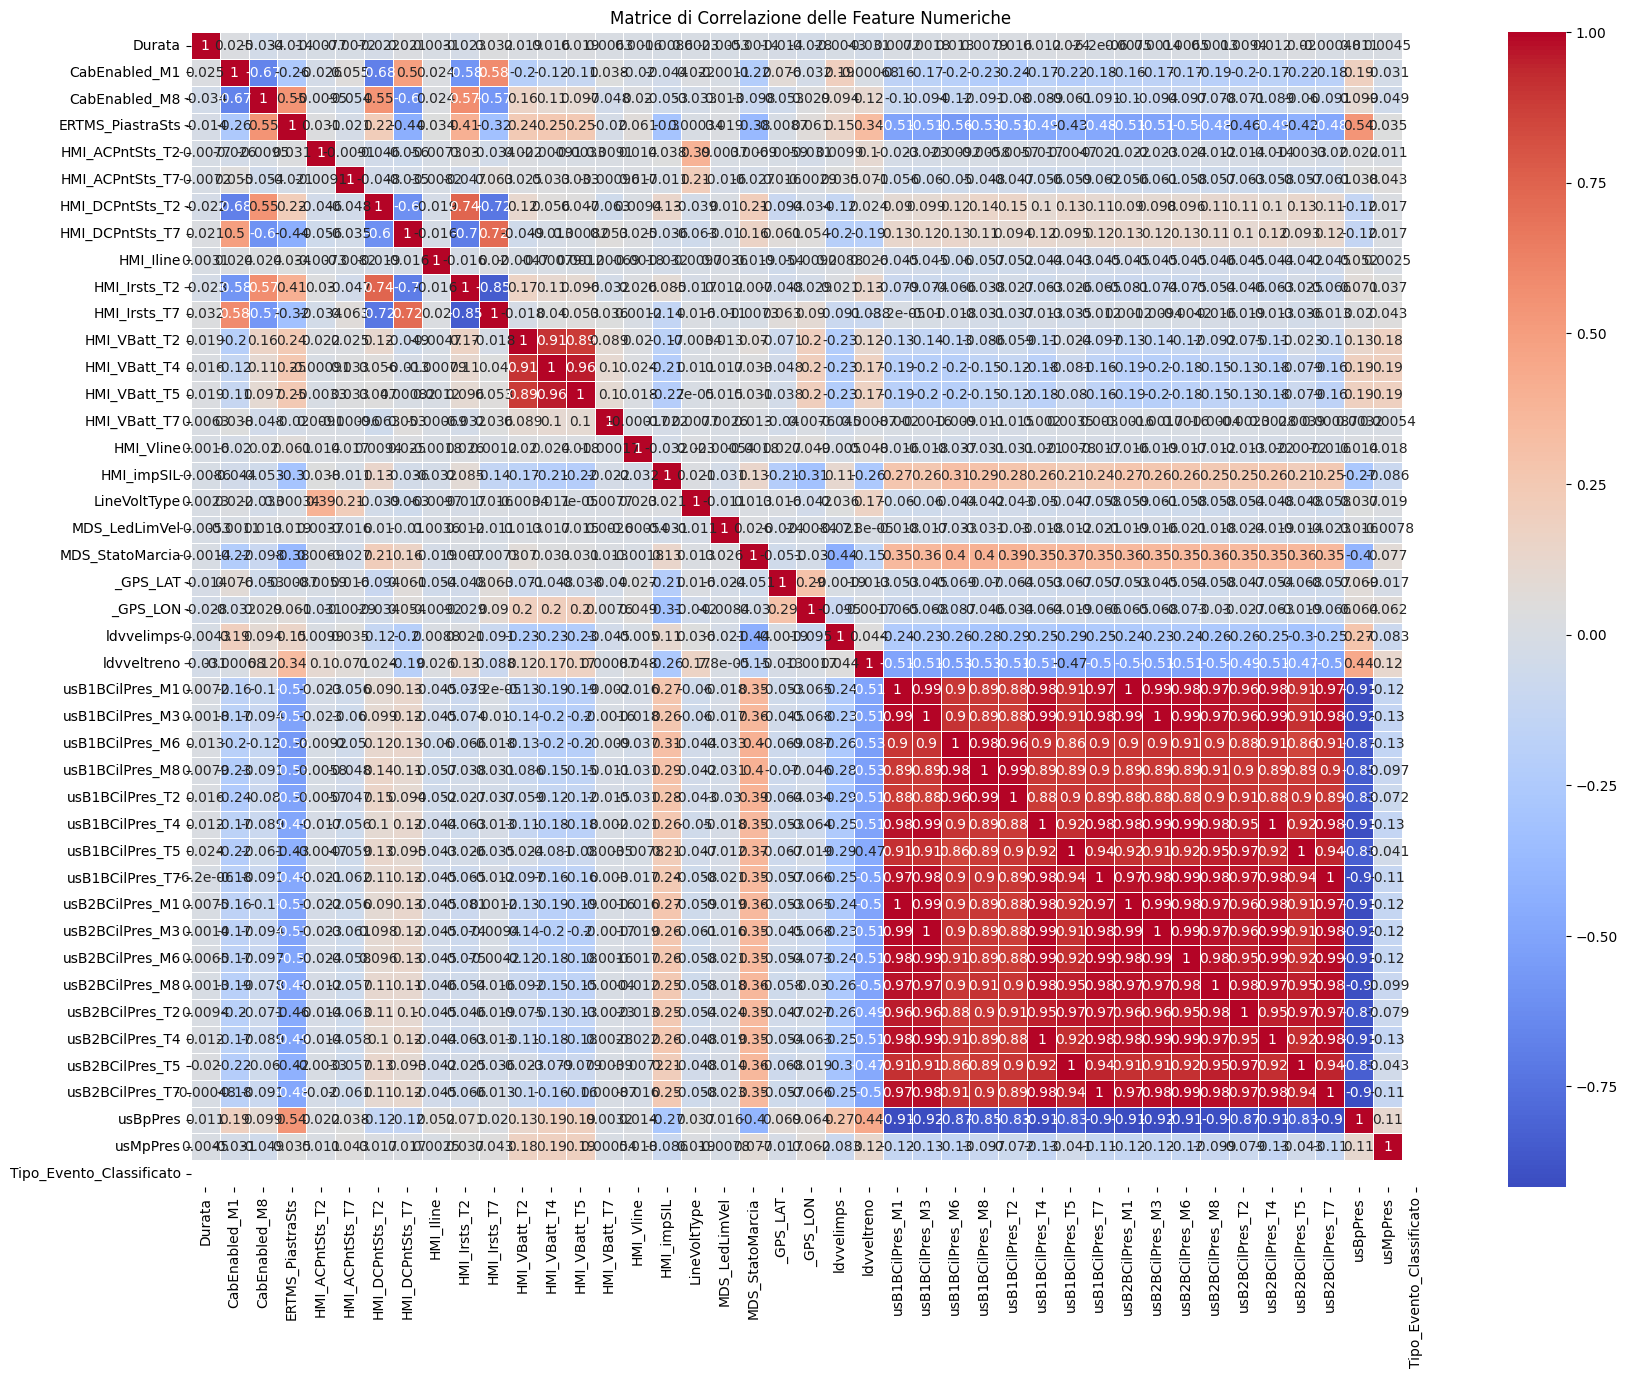

In [31]:
#matrice di correlazione dei dati sintetici con copula gaussiana
numerical_columns = synthetic_us_anomalie.select_dtypes(include=['float64', 'int64']).columns

correlation_matrix = synthetic_us_anomalie[numerical_columns].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matrice di Correlazione delle Feature Numeriche')
plt.show()

In [ ]:
#matrice di #matrice di correlazione dei dati sintetici con copula gaussiana
numerical_columns = synthetic_us_normali.select_dtypes(include=['float64', 'int64']).columns

correlation_matrix = synthetic_us_normali[numerical_columns].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matrice di Correlazione delle Feature Numeriche')
plt.show()

NameError: name 'synthetic_us_normali' is not defined

In [33]:
#funzione per plottare la matrice di confusione
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=['Anomalia', 'Funzionamento Normale'])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Anomalia', 'Funzionamento Normale'], 
                yticklabels=['Anomalia', 'Funzionamento Normale'])
    plt.xlabel('Predizione')
    plt.ylabel('Valore Reale')
    plt.title(title)
    plt.show()

Accuratezza del modello sui dati sintetici (anomalie): 0.7046
Report di classificazione sui dati sintetici (anomalie):
                       precision    recall  f1-score   support

             Anomalia       1.00      0.70      0.83      1828
Funzionamento Normale       0.00      1.00      0.00         0

             accuracy                           0.70      1828
            macro avg       0.50      0.85      0.41      1828
         weighted avg       1.00      0.70      0.83      1828



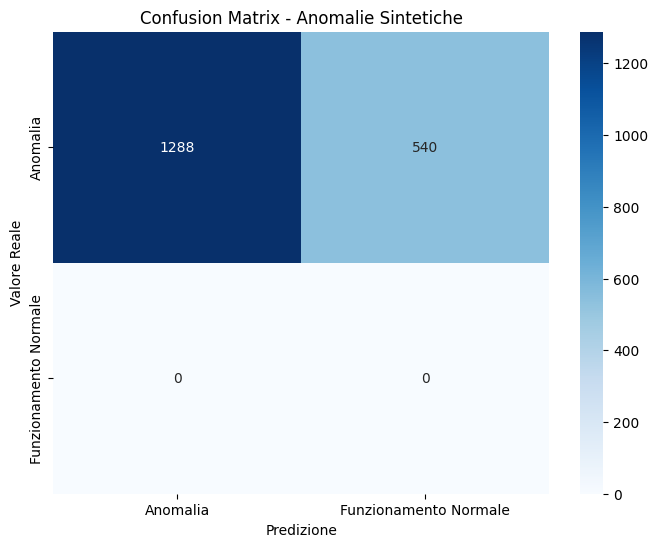

In [34]:
#testiamo il modello sulle anomalie sintetiche
X_sintetici_anomalie = synthetic_us_anomalie.drop(columns=[
    'Tipo_Evento_Classificato','Timestamp', 'Timestamp chiusura'], errors='ignore')

non_numeric_columns_sintetici_anomalie = X_sintetici_anomalie.select_dtypes(include=['object']).columns
X_sintetici_anomalie = X_sintetici_anomalie.drop(columns=non_numeric_columns_sintetici_anomalie)

y_sintetici_true_anomalie = ['Anomalia'] * len(X_sintetici_anomalie)
y_pred_sintetici_anomalie = rf_model.predict(X_sintetici_anomalie)

accuracy_sintetici_anomalie = accuracy_score(y_sintetici_true_anomalie, y_pred_sintetici_anomalie)
classification_rep_sintetici_anomalie = classification_report(y_sintetici_true_anomalie, y_pred_sintetici_anomalie, 
                                                              target_names=['Anomalia', 'Funzionamento Normale'], 
                                                              zero_division=1)

print(f"Accuratezza del modello sui dati sintetici (anomalie): {accuracy_sintetici_anomalie:.4f}")
print("Report di classificazione sui dati sintetici (anomalie):")
print(classification_rep_sintetici_anomalie)

plot_confusion_matrix(y_sintetici_true_anomalie, y_pred_sintetici_anomalie, 'Confusion Matrix - Anomalie Sintetiche')


Accuratezza del modello sui dati sintetici (funzionamenti normali): 0.6101
Report di classificazione sui dati sintetici (funzionamenti normali):
                       precision    recall  f1-score   support

             Anomalia       0.00      1.00      0.00         0
Funzionamento Normale       1.00      0.61      0.76      2198

             accuracy                           0.61      2198
            macro avg       0.50      0.81      0.38      2198
         weighted avg       1.00      0.61      0.76      2198



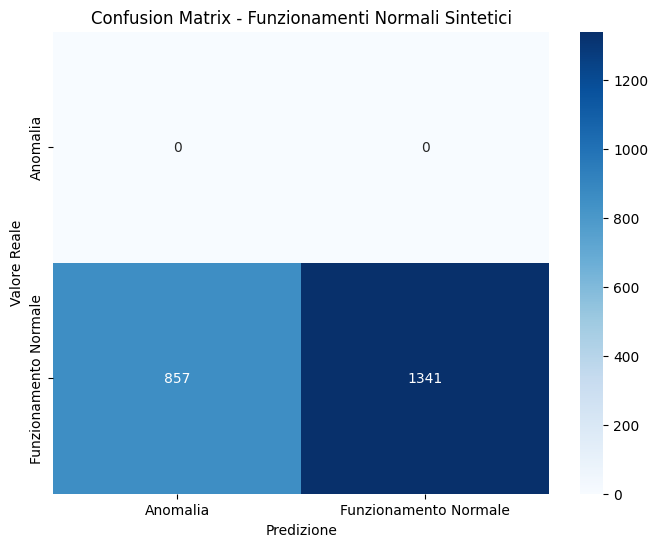

In [35]:
#testiamo il modello sui funzionamenti normali sintetiche
X_sintetici_normali = synthetic_us_normali.drop(columns=[
    'Tipo_Evento_Classificato', 'Timestamp', 'Timestamp chiusura'], errors='ignore')

non_numeric_columns_sintetici_normali = X_sintetici_normali.select_dtypes(include=['object']).columns
X_sintetici_normali = X_sintetici_normali.drop(columns=non_numeric_columns_sintetici_normali)

y_sintetici_true_normali = ['Funzionamento Normale'] * len(X_sintetici_normali)
y_pred_sintetici_normali = rf_model.predict(X_sintetici_normali)

accuracy_sintetici_normali = accuracy_score(y_sintetici_true_normali, y_pred_sintetici_normali)
classification_rep_sintetici_normali = classification_report(y_sintetici_true_normali, y_pred_sintetici_normali, 
                                                             target_names=['Anomalia', 'Funzionamento Normale'], 
                                                             zero_division=1)

print(f"Accuratezza del modello sui dati sintetici (funzionamenti normali): {accuracy_sintetici_normali:.4f}")
print("Report di classificazione sui dati sintetici (funzionamenti normali):")
print(classification_rep_sintetici_normali)

plot_confusion_matrix(y_sintetici_true_normali, y_pred_sintetici_normali, 'Confusion Matrix - Funzionamenti Normali Sintetici')

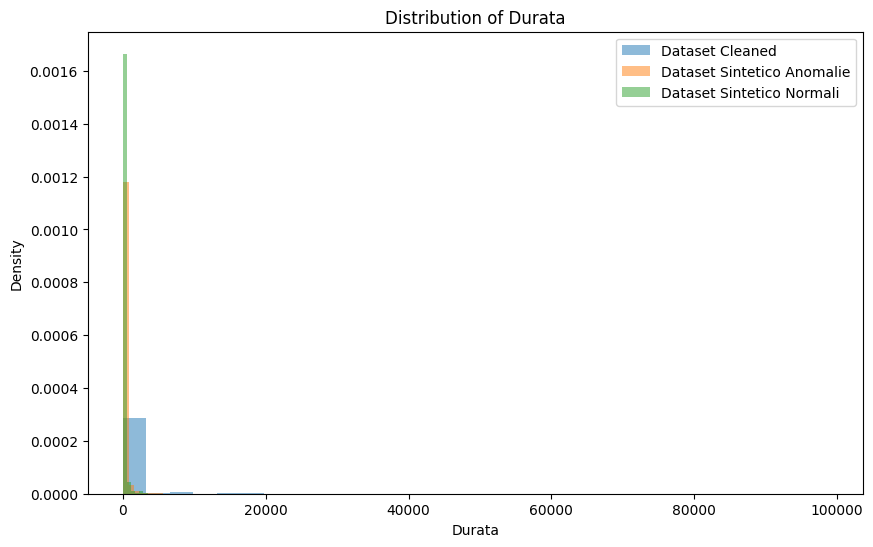

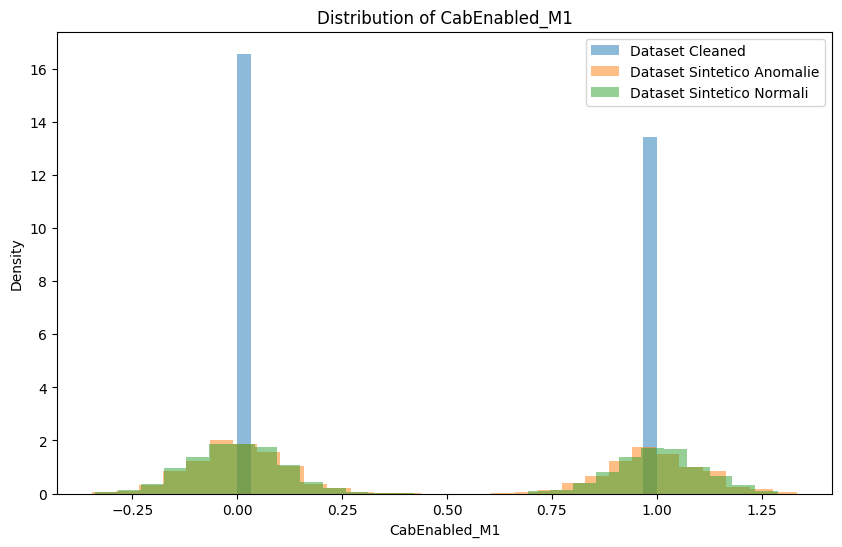

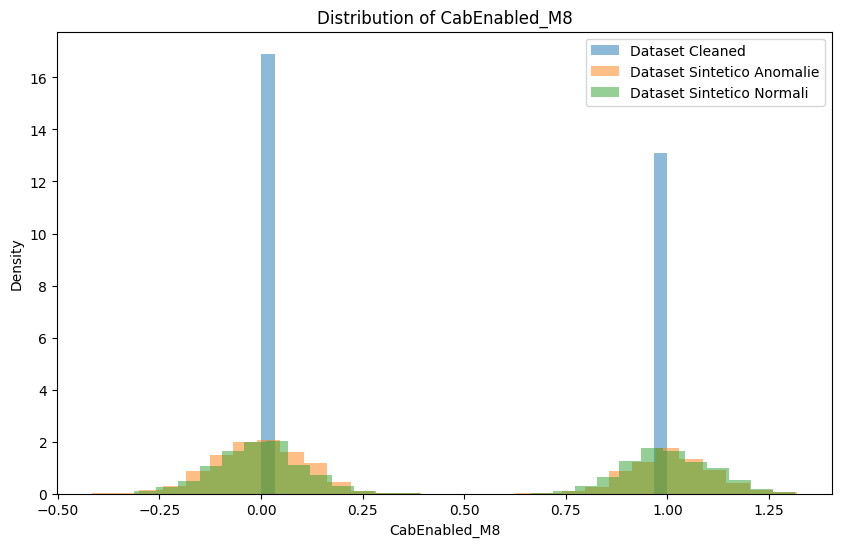

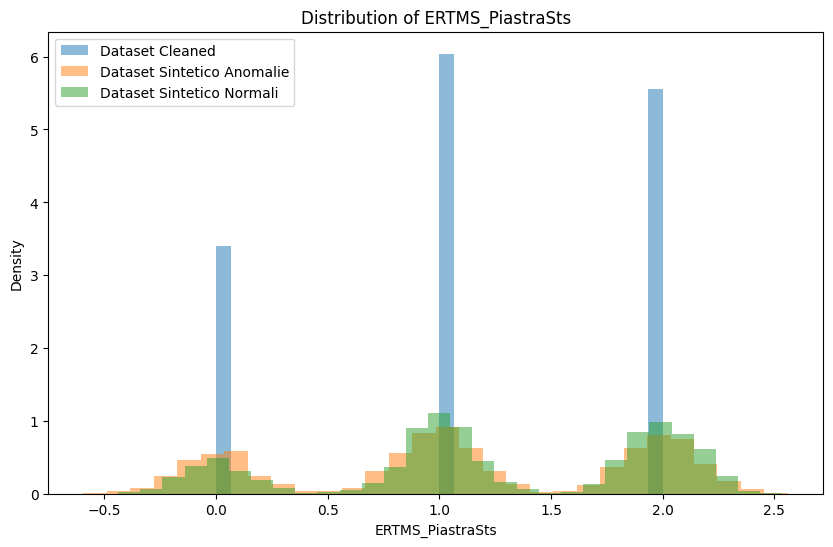

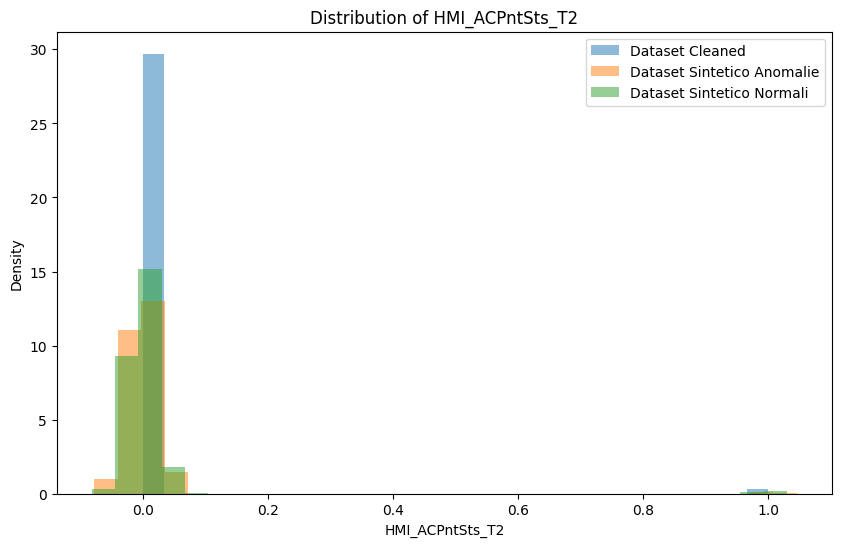

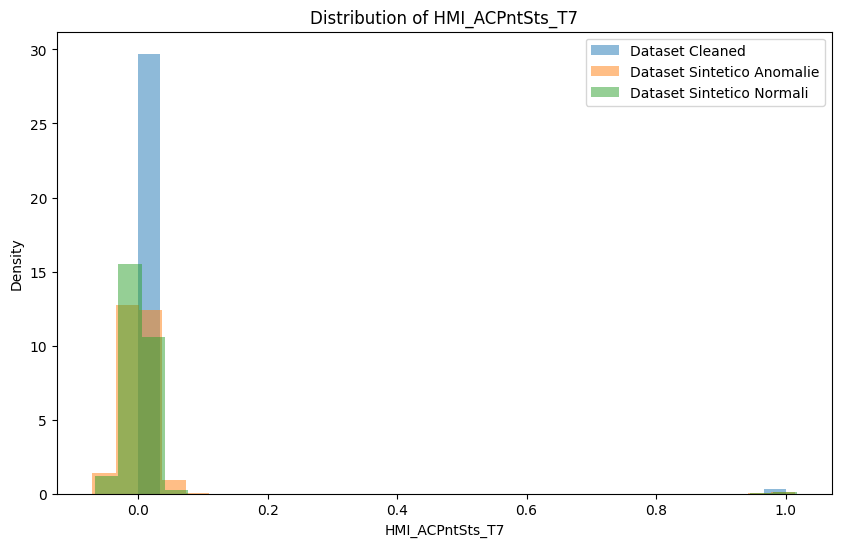

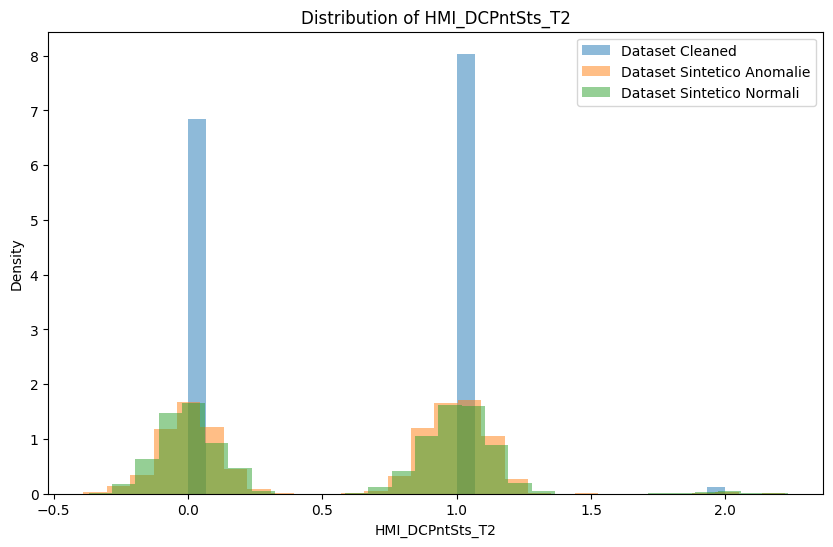

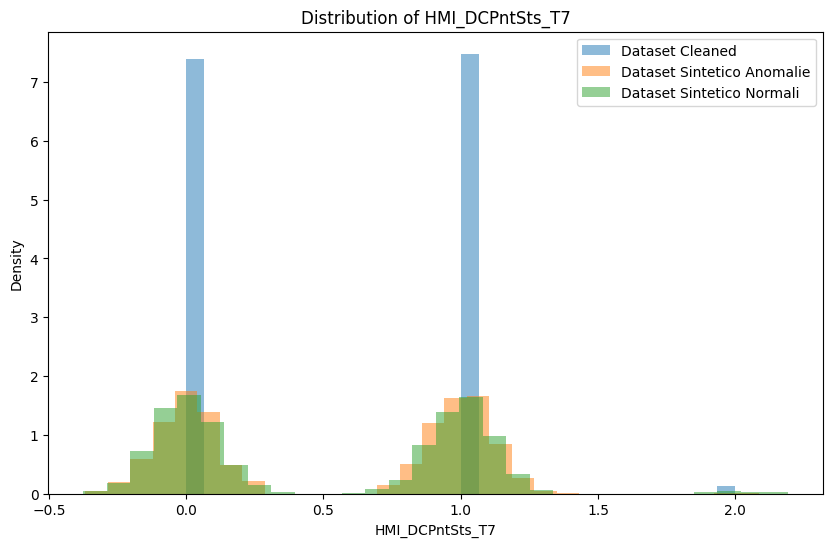

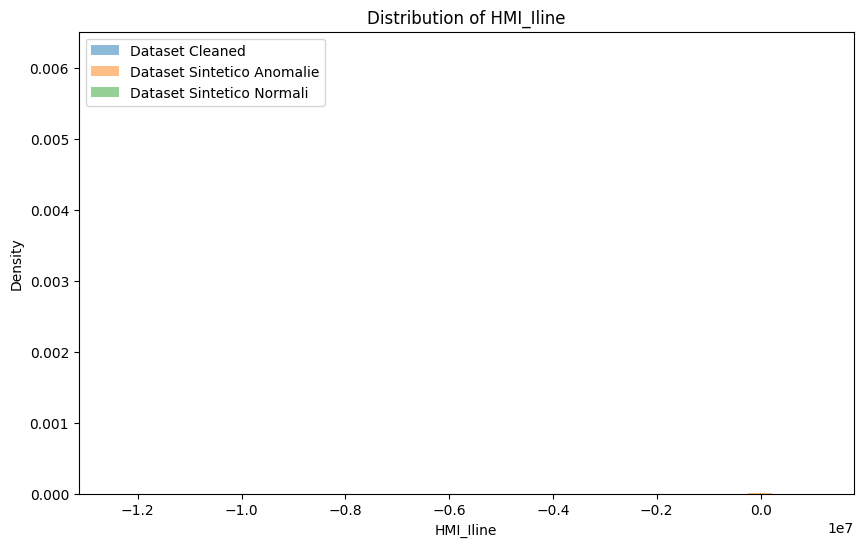

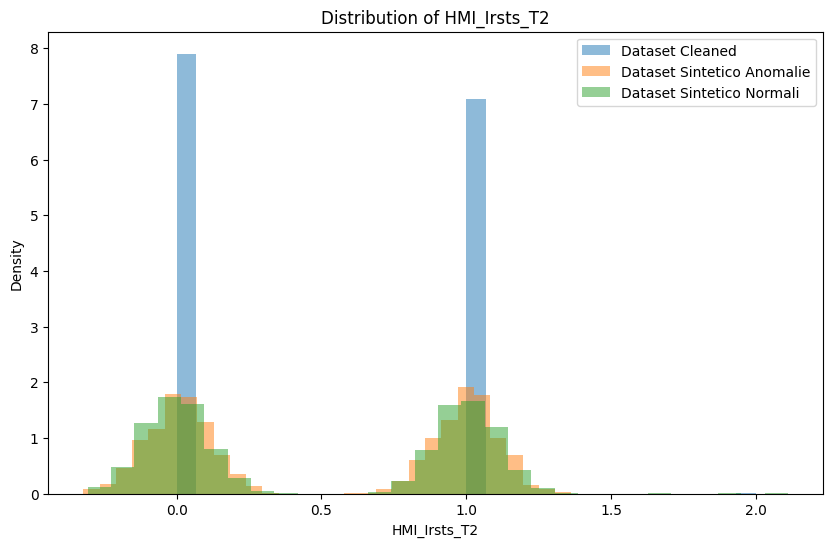

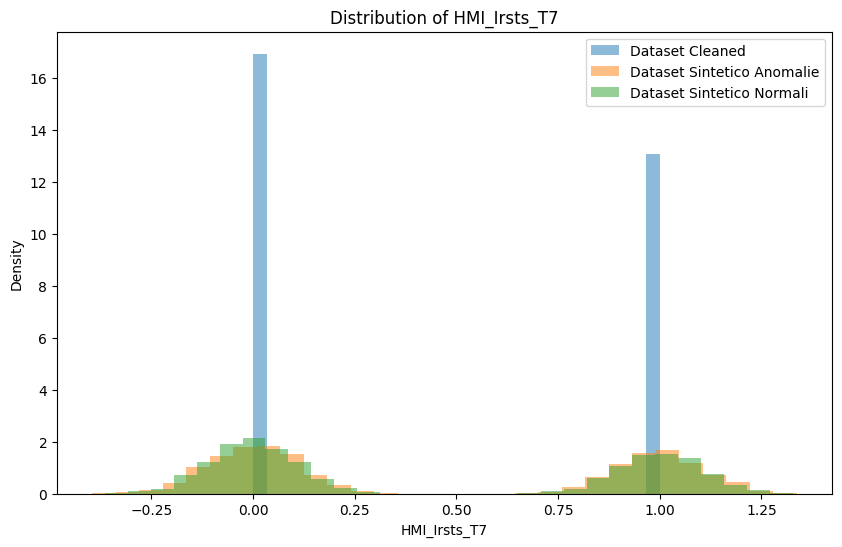

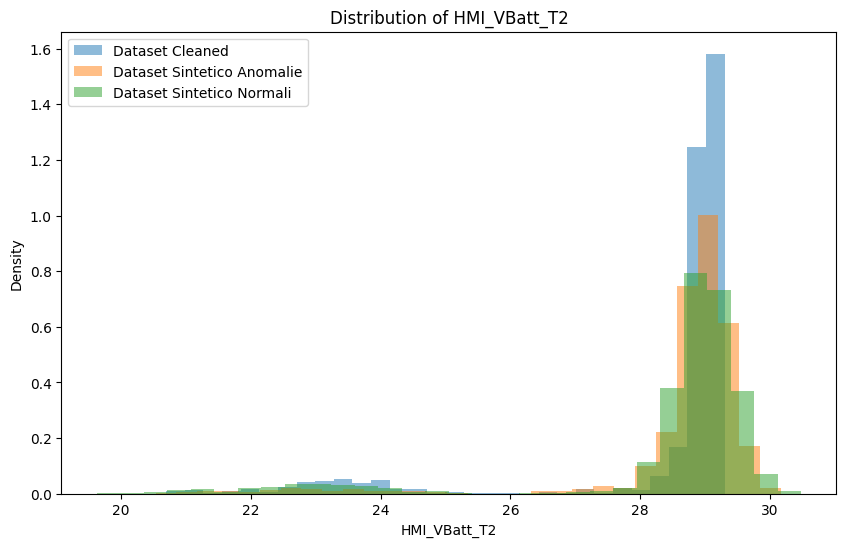

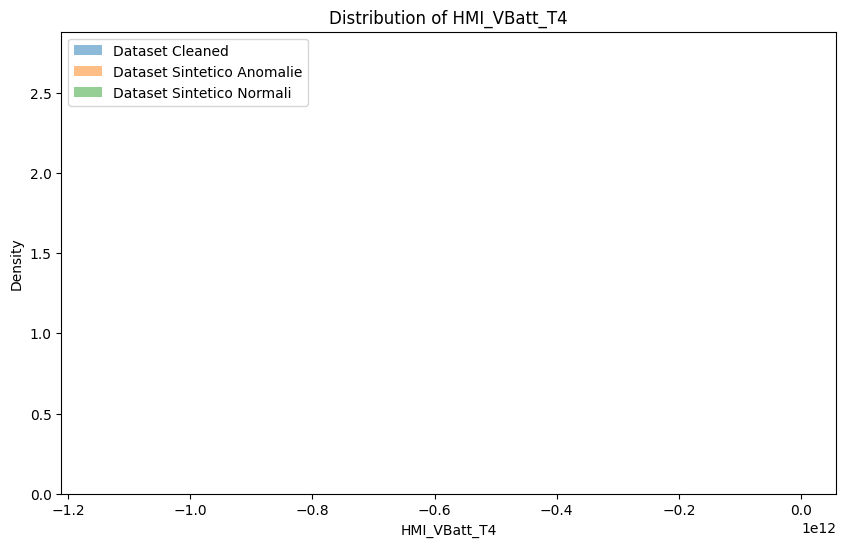

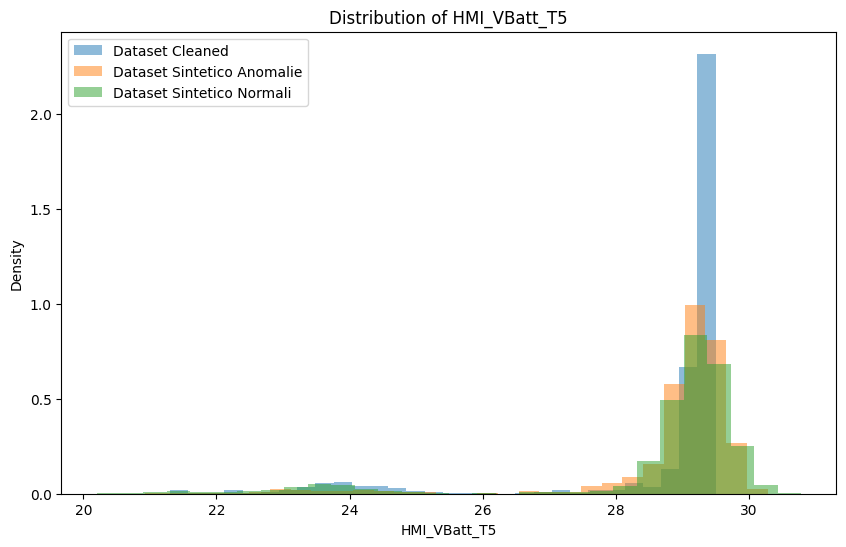

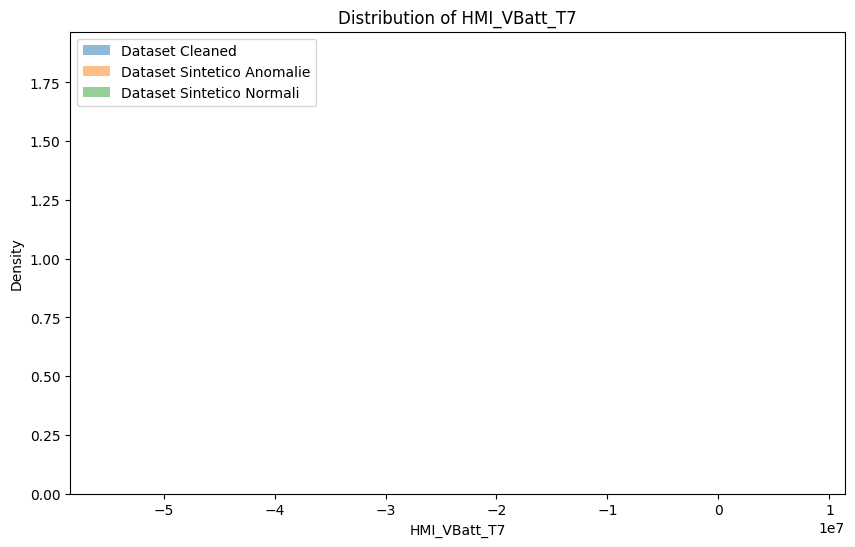

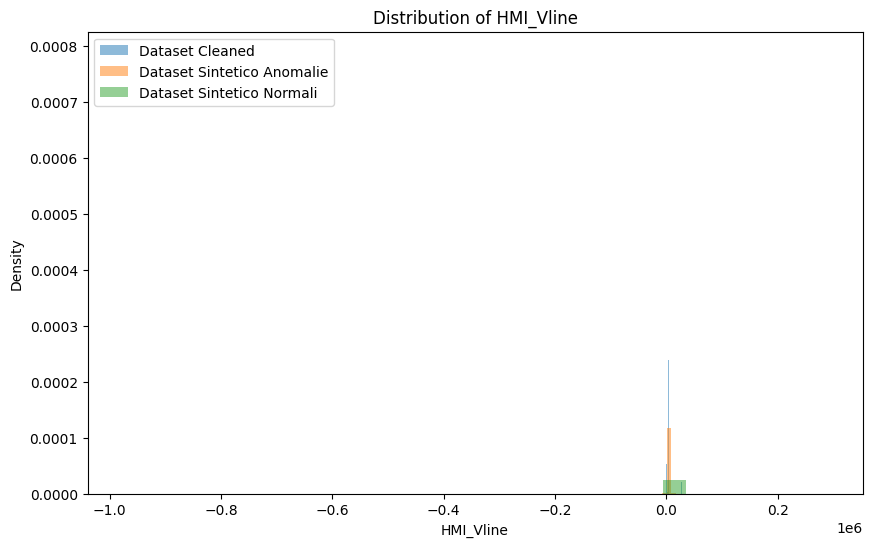

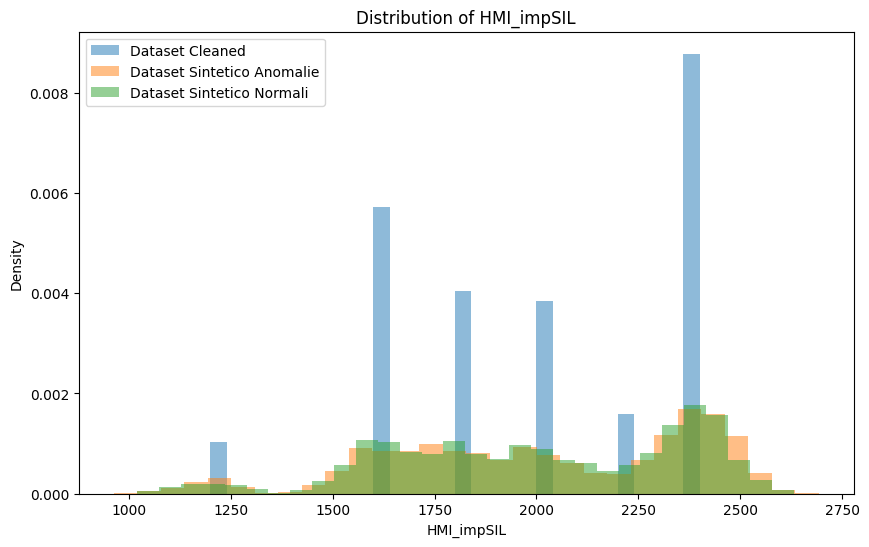

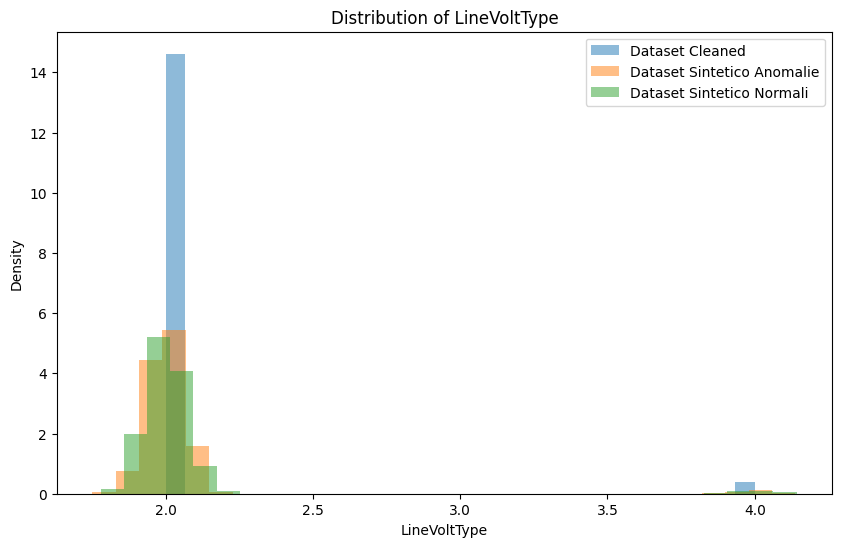

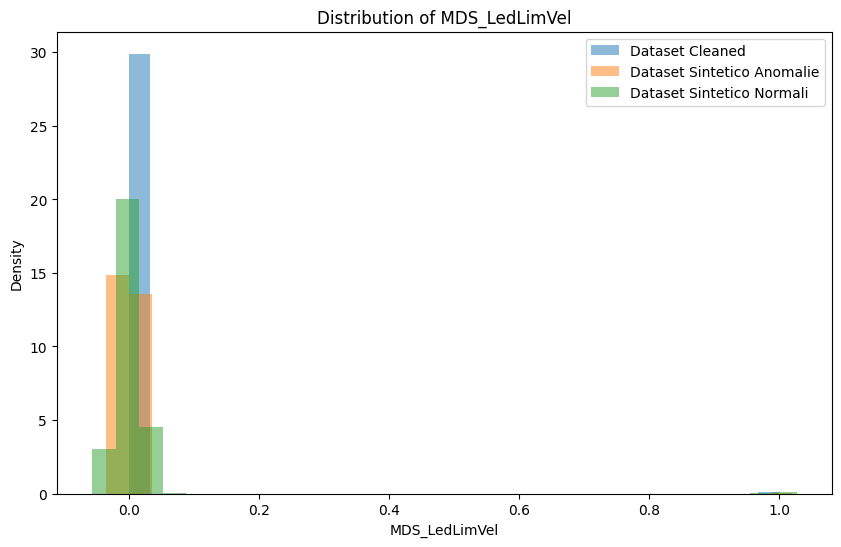

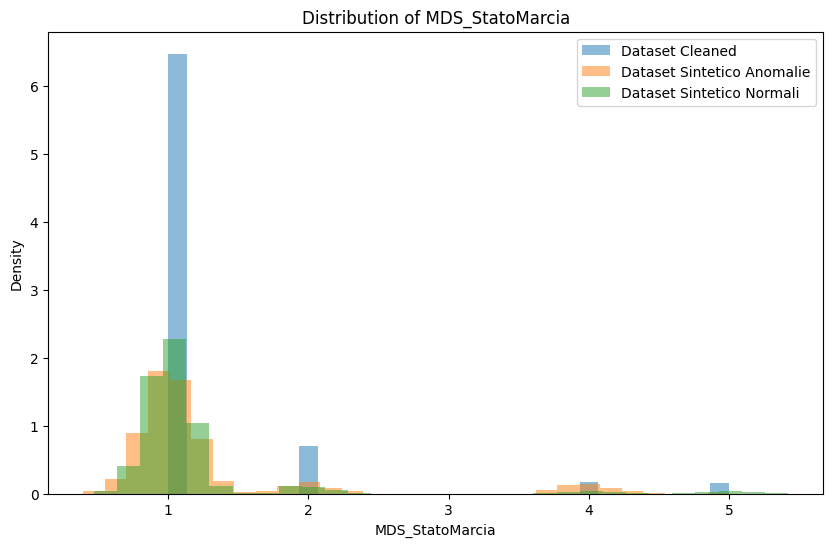

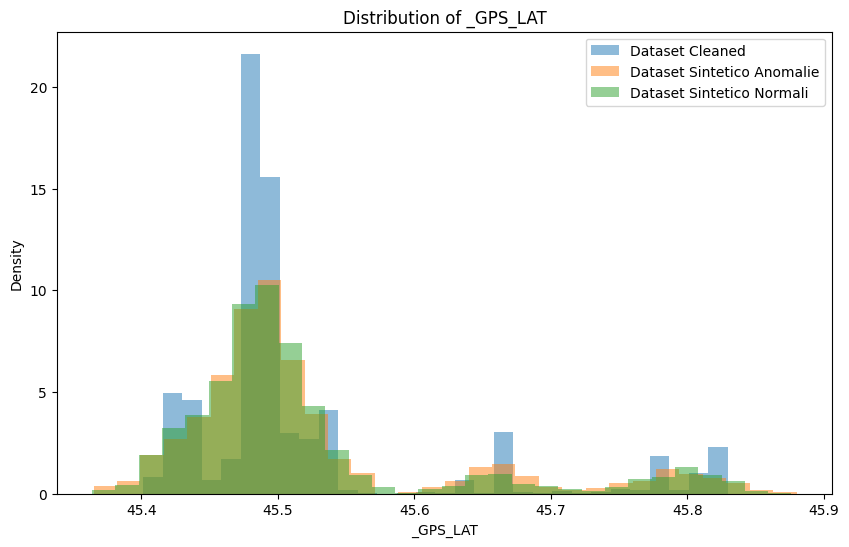

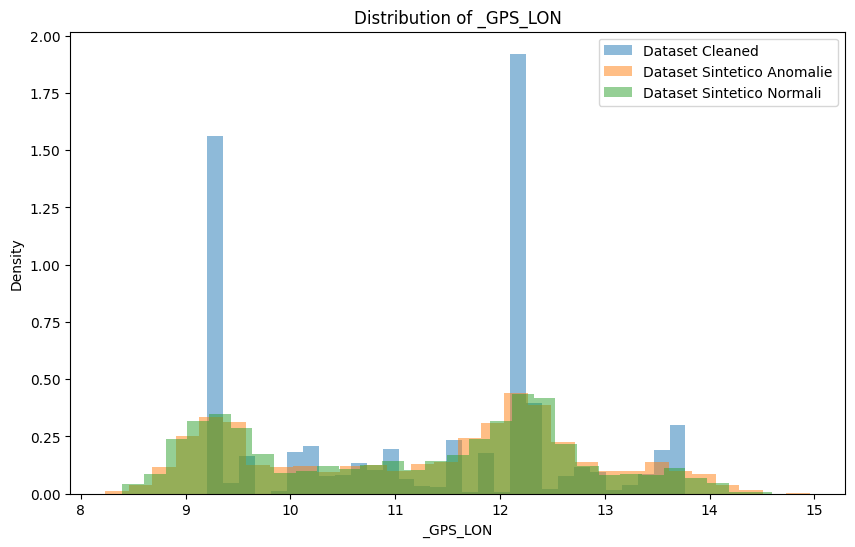

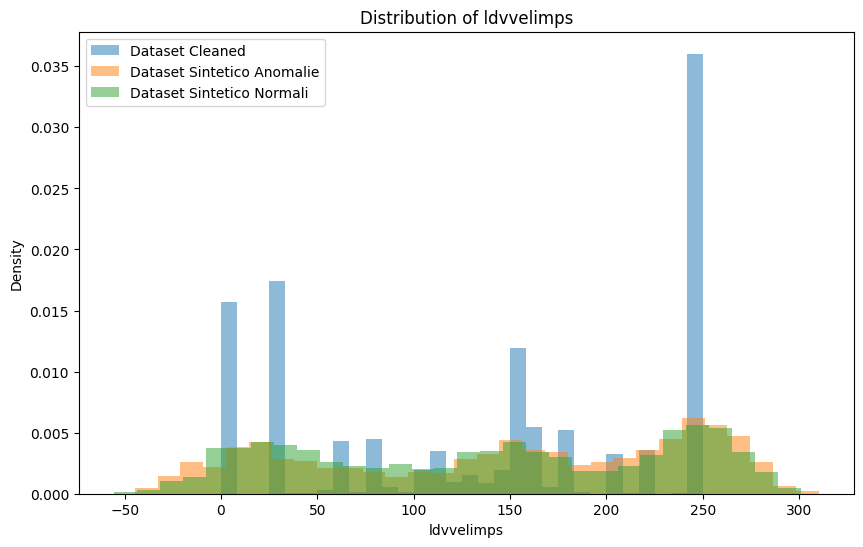

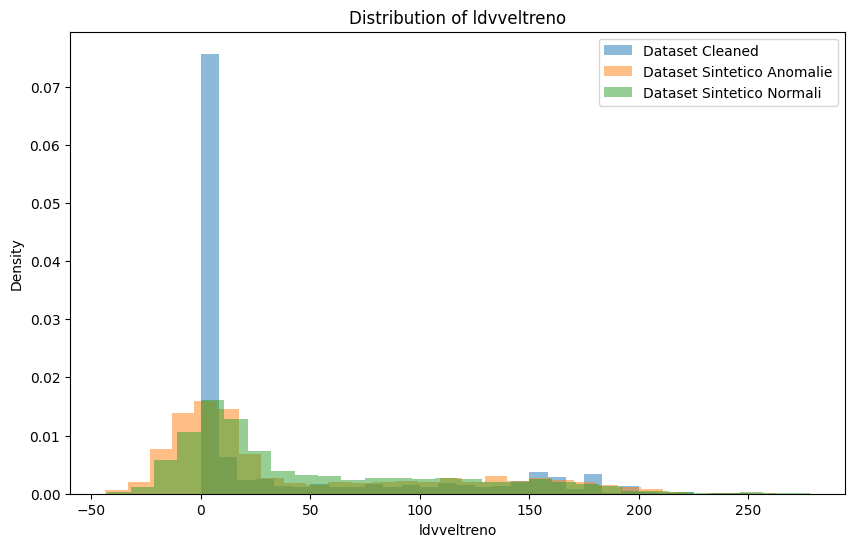

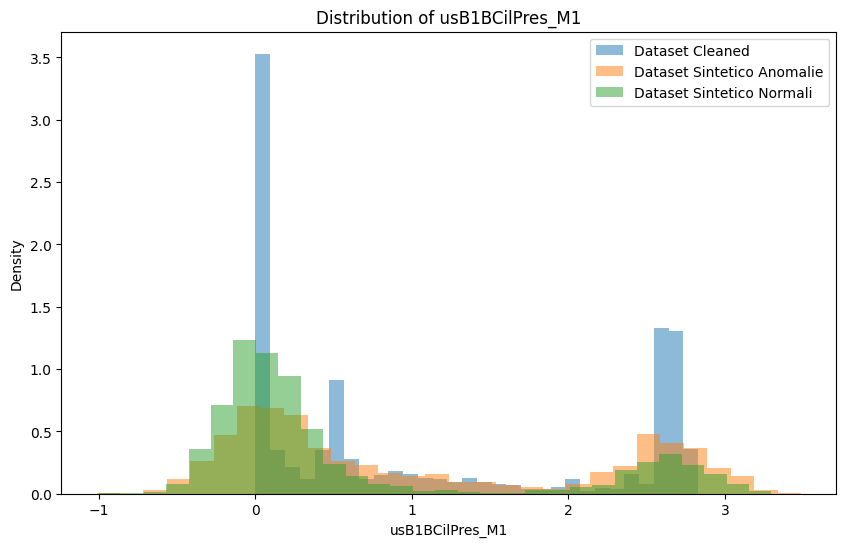

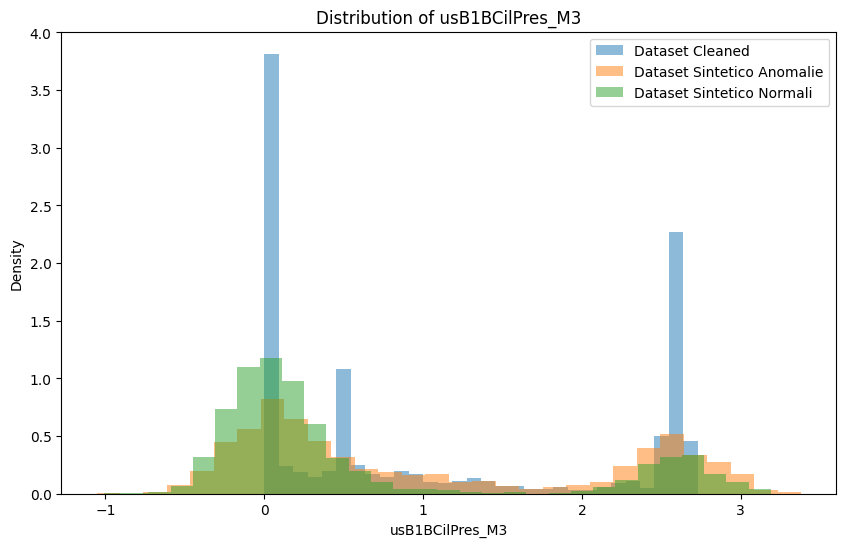

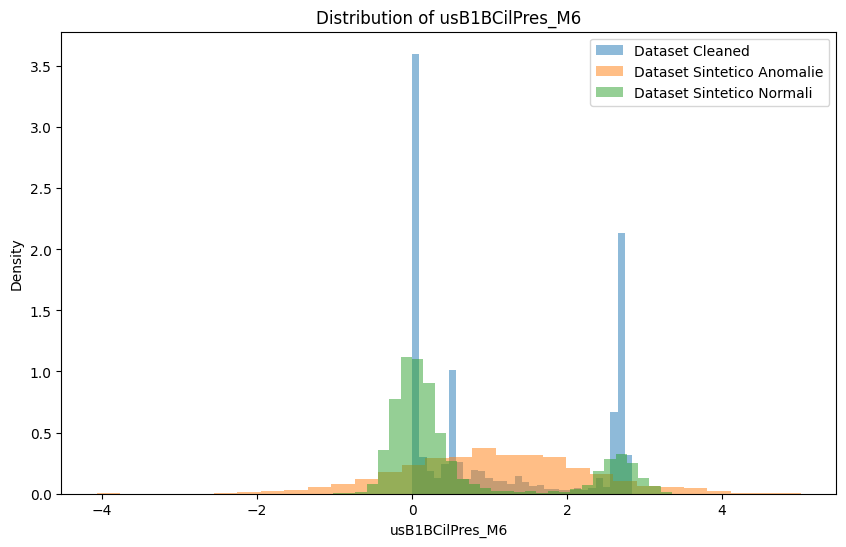

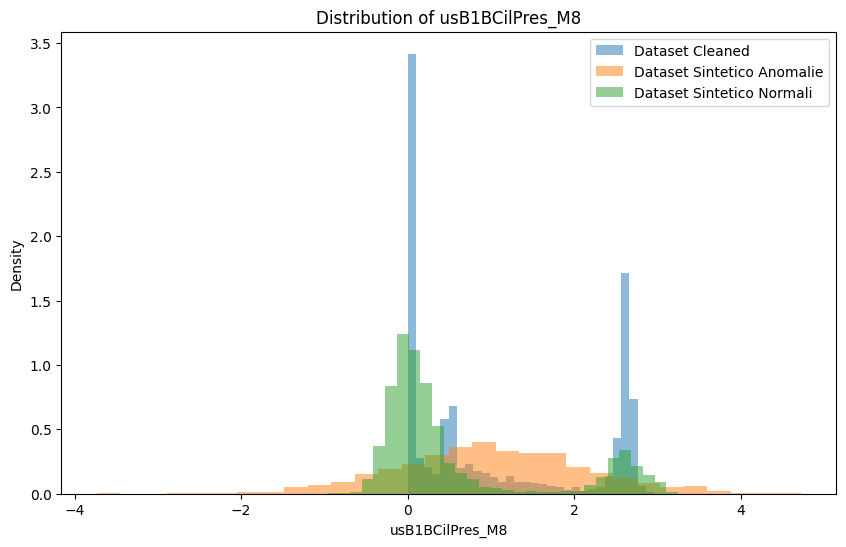

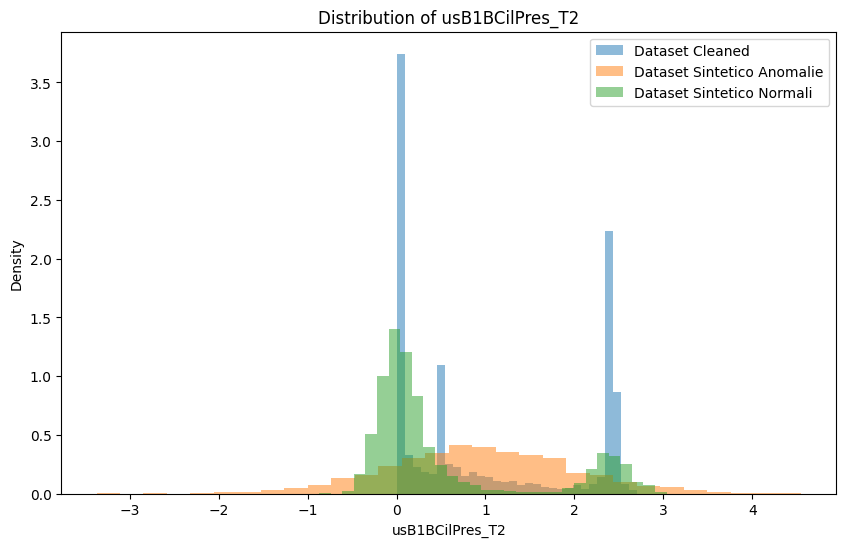

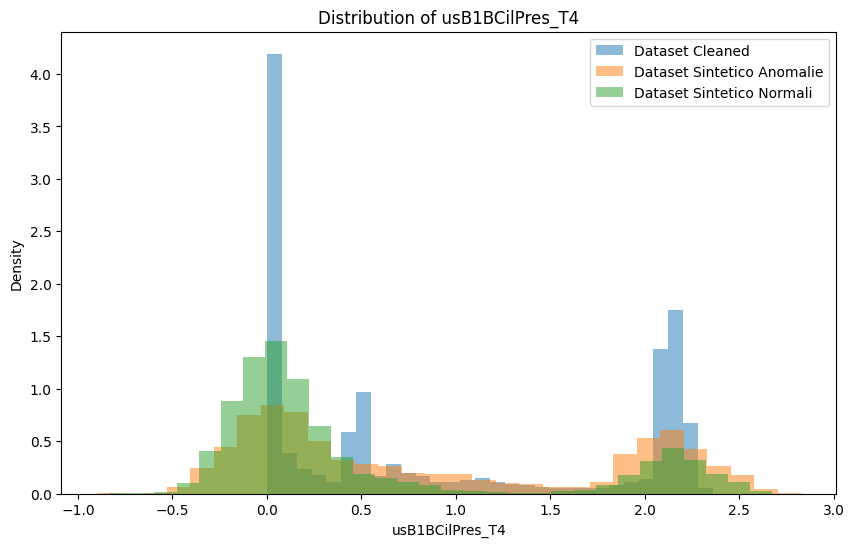

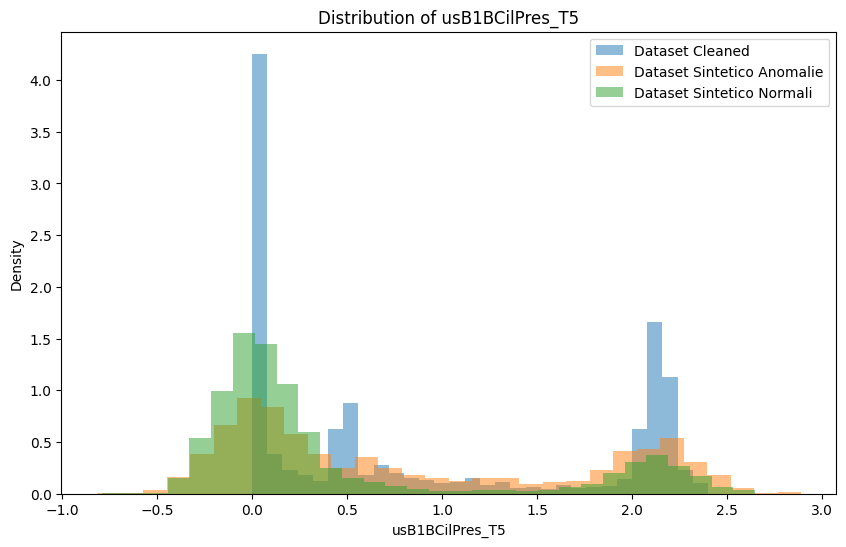

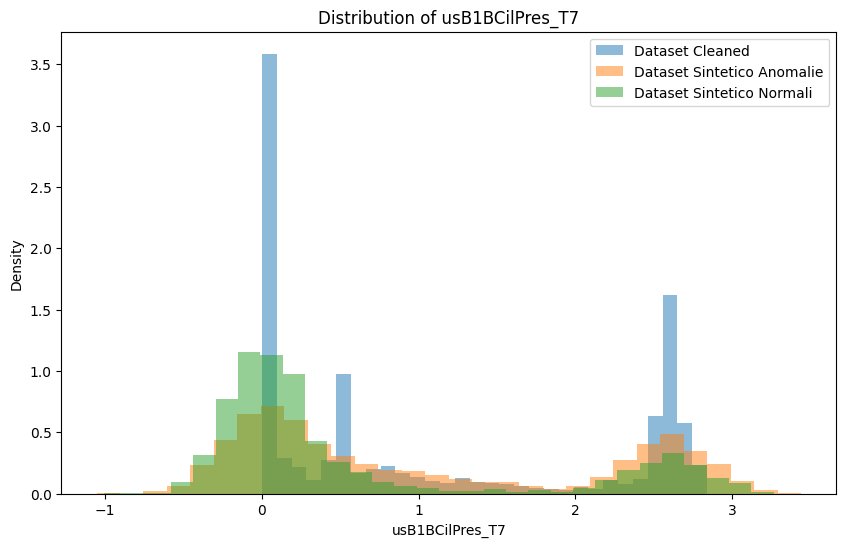

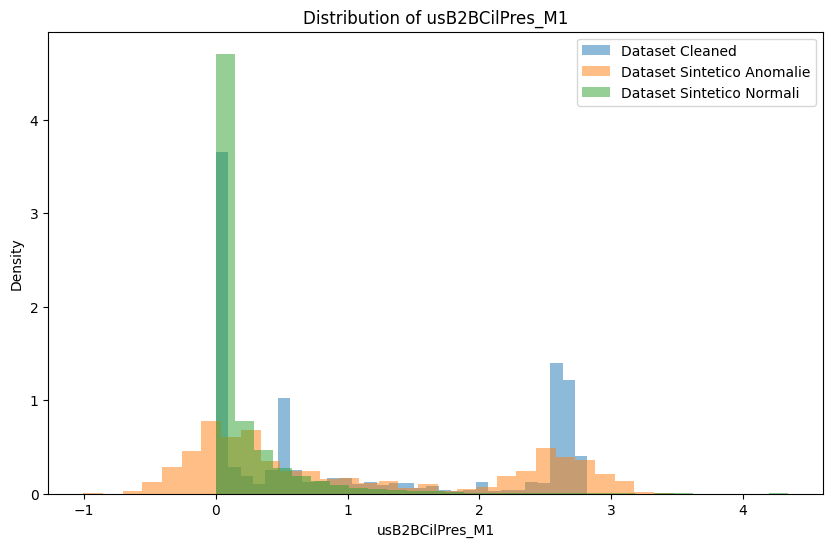

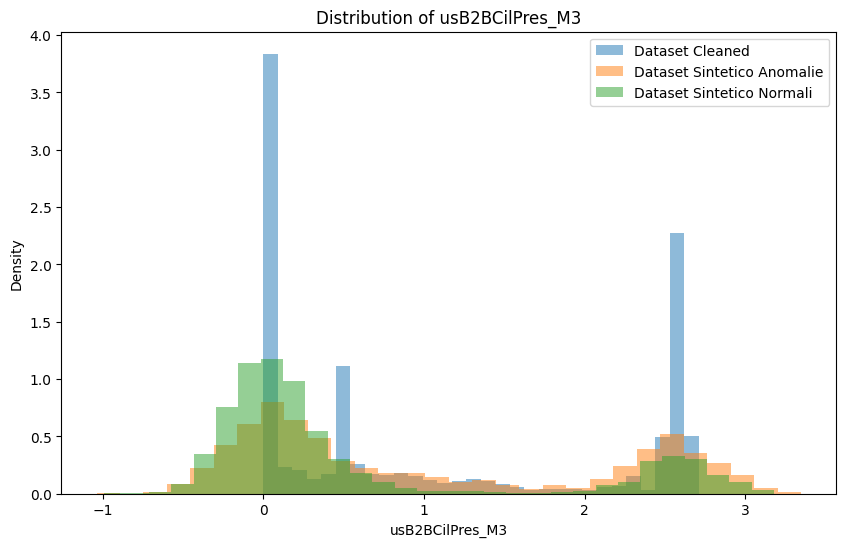

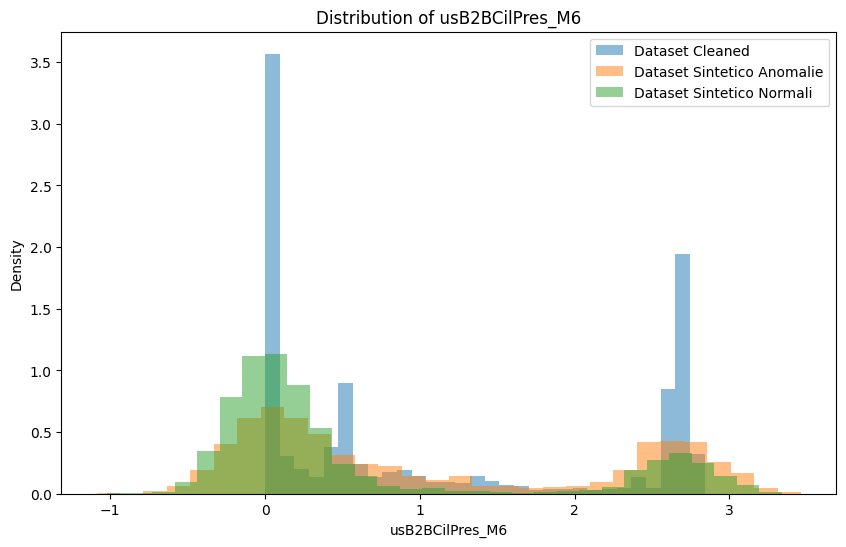

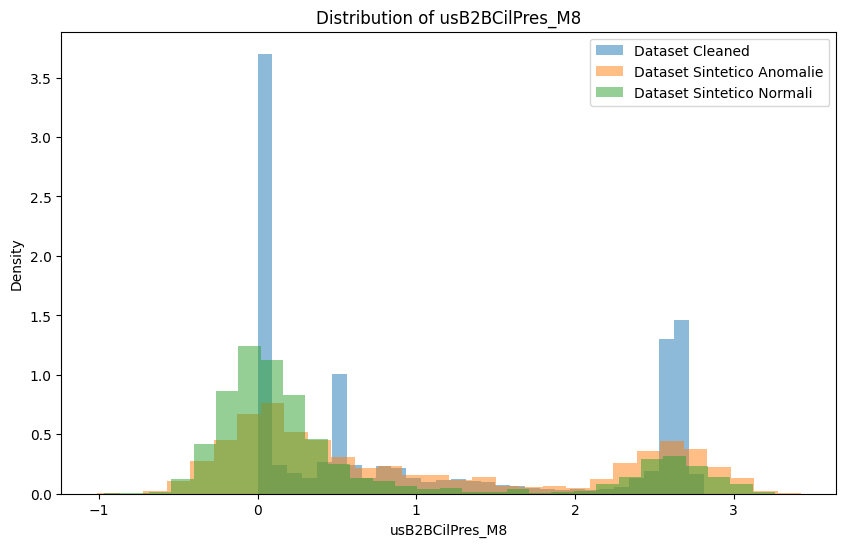

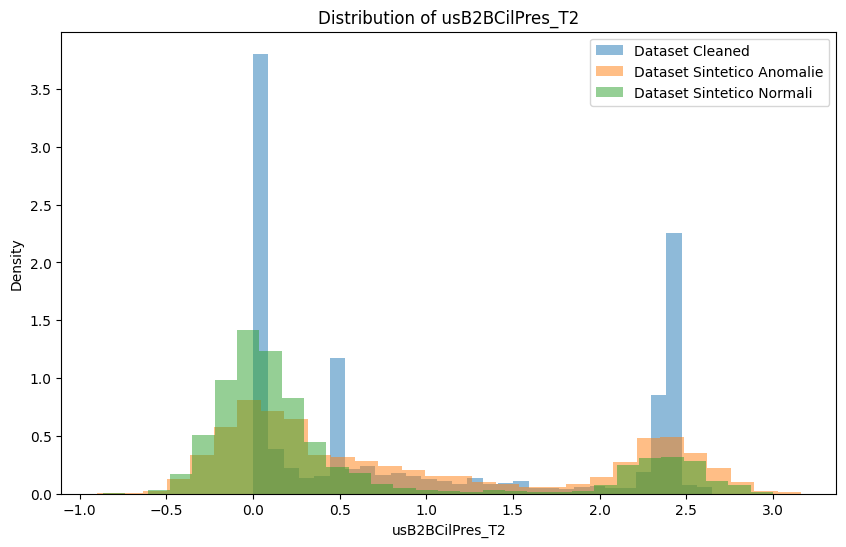

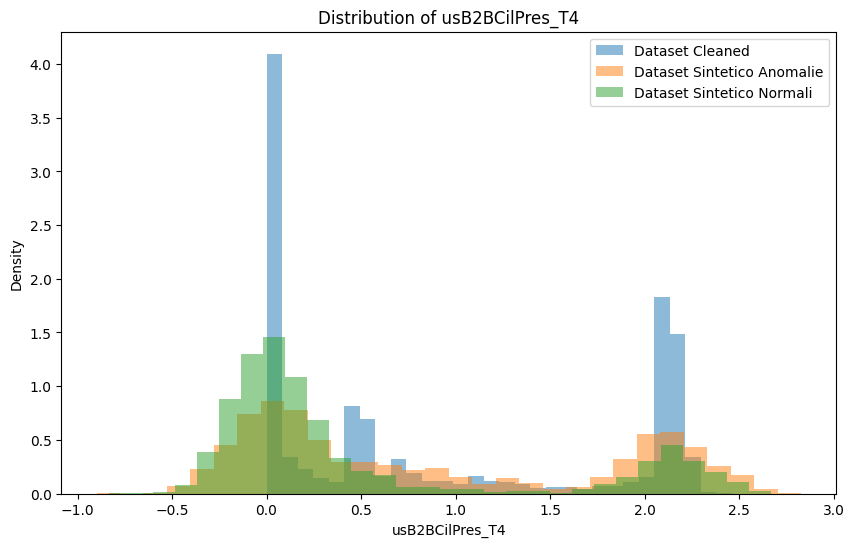

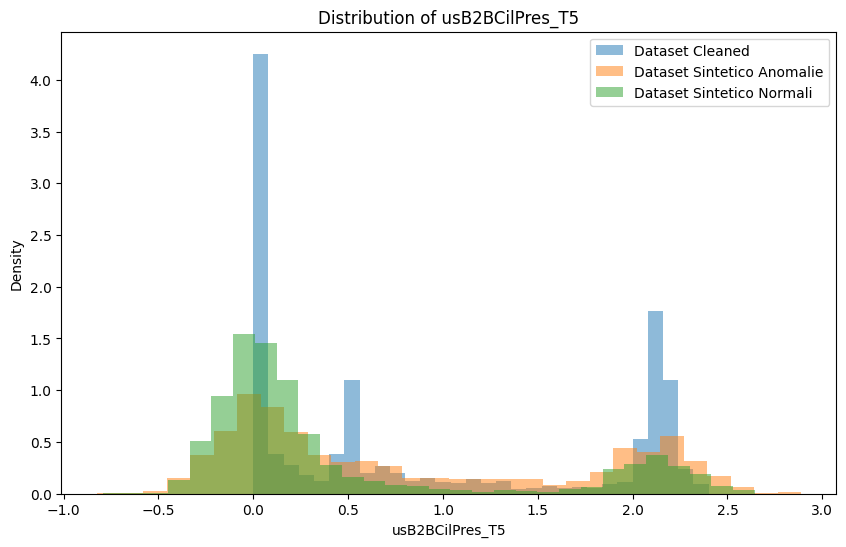

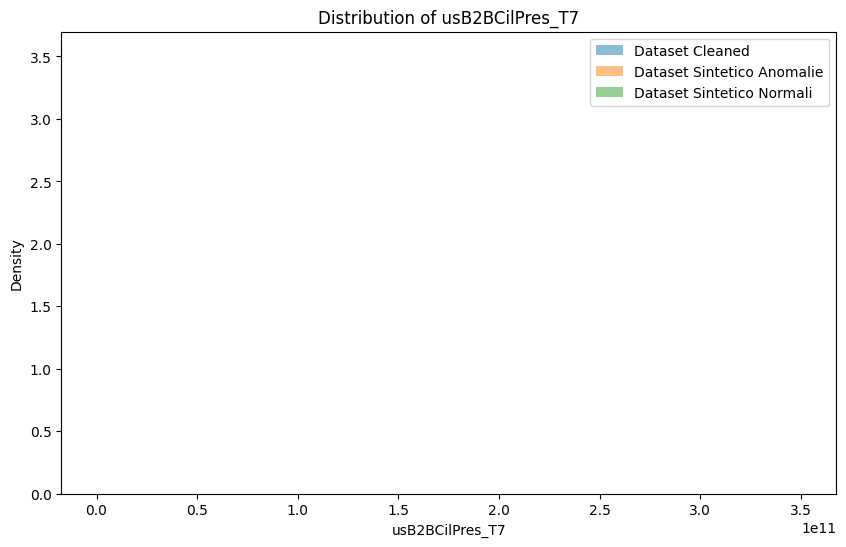

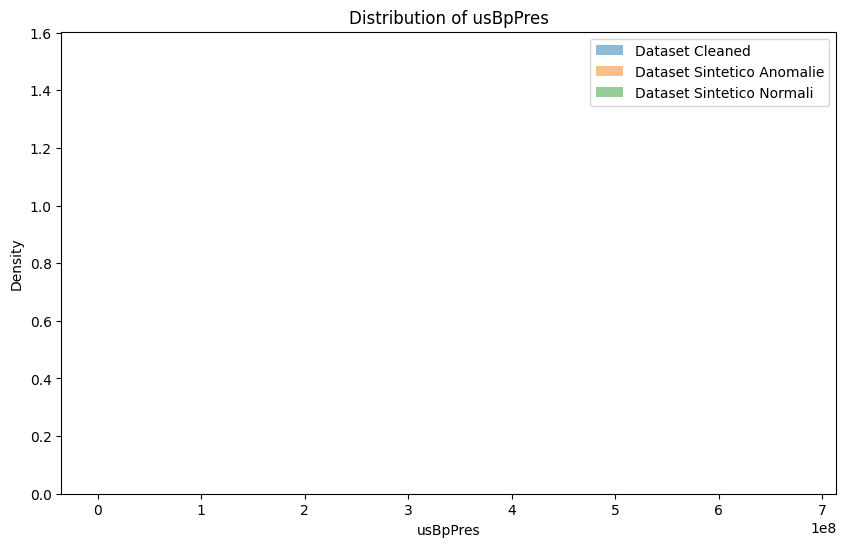

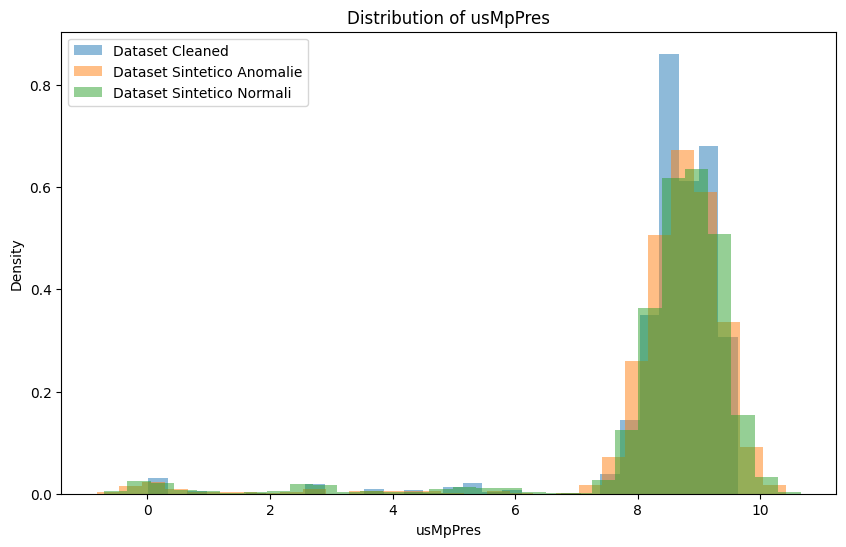

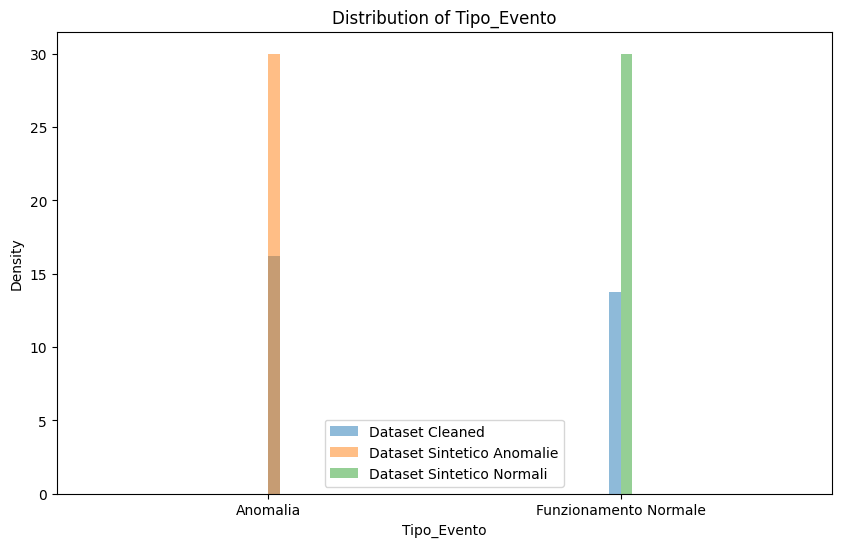

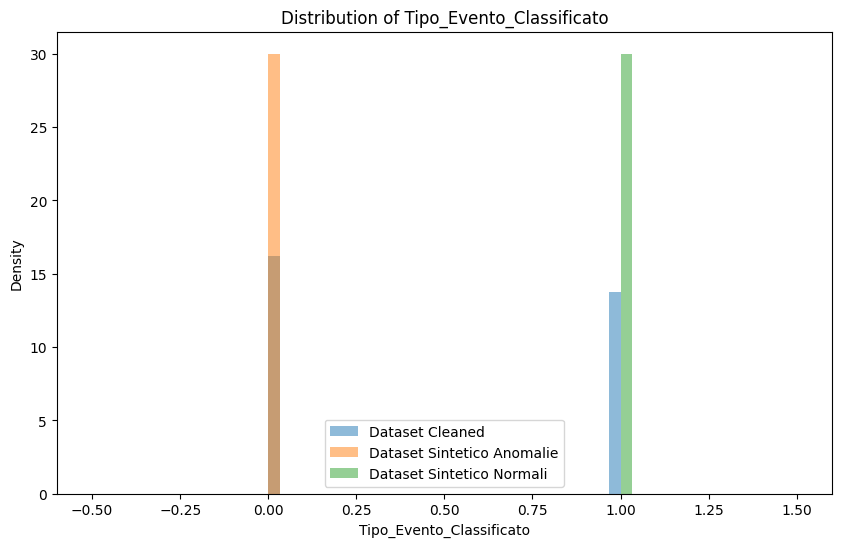

In [36]:
#rappresentazione grafica delle distribuzioni
dataset_cleaned = pd.read_csv('dataset_cleaned.csv')
dataset_sintetico_anomalie = pd.read_csv('dataset_sintetico_anomalie.csv')
dataset_sintetico_normali = pd.read_csv('dataset_sintetico_normali.csv')

common_columns = dataset_sintetico_anomalie.columns.intersection(dataset_sintetico_normali.columns)

filtered_dataset_cleaned = dataset_cleaned[common_columns]

plt.rcParams["figure.figsize"] = (10, 6)

for column in common_columns:
    plt.figure()
    plt.hist(filtered_dataset_cleaned[column].dropna(), bins=30, alpha=0.5, label='Dataset Cleaned', density=True)
    plt.hist(dataset_sintetico_anomalie[column].dropna(), bins=30, alpha=0.5, label='Dataset Sintetico Anomalie', density=True)
    plt.hist(dataset_sintetico_normali[column].dropna(), bins=30, alpha=0.5, label='Dataset Sintetico Normali', density=True)
    
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Density')
    plt.legend()
    plt.show()


In [ ]:
#script per la generazione continua di dati sintetici
import pandas as pd
import numpy as np
import time
from concurrent.futures import ThreadPoolExecutor
from copulas.multivariate import GaussianMultivariate
import warnings
import os
from datetime import timedelta
from random import uniform

columns_to_generate = [
    'Durata', 'CabEnabled_M1', 'CabEnabled_M8', 'ERTMS_PiastraSts', 'HMI_ACPntSts_T2', 'HMI_ACPntSts_T7',
    'HMI_DCPntSts_T2', 'HMI_DCPntSts_T7', 'HMI_Iline', 'HMI_Irsts_T2', 'HMI_Irsts_T7', 'HMI_VBatt_T2',
    'HMI_VBatt_T4', 'HMI_VBatt_T5', 'HMI_VBatt_T7', 'HMI_Vline', 'HMI_impSIL', 'LineVoltType', 'MDS_LedLimVel',
    'MDS_StatoMarcia', '_GPS_LAT', '_GPS_LON', 'ldvvelimps', 'ldvveltreno', 'usB1BCilPres_M1', 'usB1BCilPres_M3',
    'usB1BCilPres_M6', 'usB1BCilPres_M8', 'usB1BCilPres_T2', 'usB1BCilPres_T4', 'usB1BCilPres_T5', 'usB1BCilPres_T7',
    'usB2BCilPres_M1', 'usB2BCilPres_M3', 'usB2BCilPres_M6', 'usB2BCilPres_M8', 'usB2BCilPres_T2', 'usB2BCilPres_T4',
    'usB2BCilPres_T5', 'usB2BCilPres_T7', 'usBpPres', 'usMpPres'
]

all_columns = [
    'Flotta', 'Veicolo', 'Codice', 'Nome', 'Descrizione', 'Test', 'Timestamp', 'Timestamp chiusura', 'Durata', 
    'Posizione', 'Sistema', 'Componente', 'Latitudine', 'Longitudine', 'Contemporaneo', 'Timestamp segnale'
] + columns_to_generate + ['Tipo_Evento', 'Tipo_Evento_Classificato']

timestamp_iniziale = pd.Timestamp.now()

def rigeneraDatasetSintetico(file_anomalie, file_normali, df_anomalie, df_normali, num_righe):
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    
    df_anomalie_copula = df_anomalie.drop(columns=['Durata'], errors='ignore')
    df_normali_copula = df_normali.drop(columns=['Durata'], errors='ignore')
    
    copula_anomalie = GaussianMultivariate()
    copula_anomalie.fit(df_anomalie_copula)
    synthetic_anomalie = copula_anomalie.sample(num_righe // 2)

    copula_normali = GaussianMultivariate()
    copula_normali.fit(df_normali_copula)
    synthetic_normali = copula_normali.sample(num_righe // 2)
    
    alpha = 0.2
    beta = 1.9
    media_durata_anomalie = 157 * alpha
    media_durata_normali = 115 * alpha
    sigma_anomalie = 1 * beta
    sigma_normali = 1 * beta

    synthetic_anomalie['Durata'] = np.random.lognormal(mean=np.log(media_durata_anomalie), sigma=sigma_anomalie, size=len(synthetic_anomalie))
    synthetic_normali['Durata'] = np.random.lognormal(mean=np.log(media_durata_normali), sigma=sigma_normali, size=len(synthetic_normali))

    for df in [synthetic_anomalie, synthetic_normali]:
        df['Flotta'] = 'ETR700'
        df['Veicolo'] = 'e700_4801'
        df['Test'] = 'N'
        df['Timestamp'] = pd.Timestamp.now()
        df['Timestamp chiusura'] = df['Timestamp'] + pd.to_timedelta(df['Durata'], unit='s')
        df['Posizione'] = np.nan
        df['Sistema'] = 'VEHICLE'
        df['Componente'] = 'VEHICLE'
        df['Timestamp segnale'] = np.nan

    for col in all_columns:
        if col not in synthetic_anomalie.columns:
            synthetic_anomalie[col] = np.nan
        if col not in synthetic_normali.columns:
            synthetic_normali[col] = np.nan

    synthetic_anomalie = synthetic_anomalie.round(2)
    synthetic_normali = synthetic_normali.round(2)

    synthetic_anomalie = synthetic_anomalie[all_columns]
    synthetic_normali = synthetic_normali[all_columns]

    synthetic_anomalie.to_csv(file_anomalie, index=False)
    synthetic_normali.to_csv(file_normali, index=False)

    warnings.filterwarnings("default", category=RuntimeWarning)
    print(f"Dataset sintetici rigenerati: {file_anomalie} e {file_normali}")

def aggiungoRigaAlFileDiDestinazione(file_output, file_anomalie, file_normali):
    global timestamp_iniziale

    if np.random.rand() < 0.5:
        dataset_file = file_anomalie
        tipo_evento = 'Anomalia'
        tipo_evento_classificato = 0
    else:
        dataset_file = file_normali
        tipo_evento = 'Funzionamento Normale'
        tipo_evento_classificato = 1

    dataset_sintetico = pd.read_csv(dataset_file)
    nuova_riga = dataset_sintetico.iloc[0].copy()
    dataset_sintetico = dataset_sintetico.iloc[1:]

    nuova_riga['Timestamp'] = timestamp_iniziale
    nuova_riga['Timestamp chiusura'] = timestamp_iniziale + pd.to_timedelta(nuova_riga['Durata'], unit='s')
    nuova_riga['Timestamp segnale'] = timestamp_iniziale + timedelta(seconds=uniform(0, 1))

    nuova_riga['Tipo_Evento'] = tipo_evento
    nuova_riga['Tipo_Evento_Classificato'] = tipo_evento_classificato

    if not os.path.exists(file_output):
        nuova_riga.to_frame().T.to_csv(file_output, mode='a', header=all_columns, index=False)
    else:
        nuova_riga.to_frame().T.to_csv(file_output, mode='a', header=False, index=False)

    dataset_sintetico.to_csv(dataset_file, index=False)

    timestamp_iniziale = pd.Timestamp.now()
    print(f"Riga sintetica aggiunta dal dataset {tipo_evento}")

def generazioneContinuataDataset(file_output, file_anomalie, file_normali, df_anomalie, df_normali, soglia=100, num_righe_rigenerazione=1000):
    executor = ThreadPoolExecutor(max_workers=2)
    rigenerazione_in_corso = None
    
    while True:
        dataset_anomalie = pd.read_csv(file_anomalie)
        dataset_normali = pd.read_csv(file_normali)

        if (len(dataset_anomalie) < soglia or len(dataset_normali) < soglia) and rigenerazione_in_corso is None:
            rigenerazione_in_corso = executor.submit(
                rigeneraDatasetSintetico, file_anomalie, file_normali, df_anomalie, df_normali, num_righe_rigenerazione
            )
            print("Rigenerazione del dataset sintetico avviata in parallelo.")

        durata = dataset_anomalie.iloc[0].get('Durata', 1) if np.random.rand() < 0.5 else dataset_normali.iloc[0].get('Durata', 1)
        time.sleep(durata)
        aggiungoRigaAlFileDiDestinazione(file_output, file_anomalie, file_normali)

        if rigenerazione_in_corso and rigenerazione_in_corso.done():
            print("Rigenerazione completata.")
            rigenerazione_in_corso = None

df_originale = pd.read_csv('dataset_cleaned.csv')
df_anomalie = df_originale[df_originale['Tipo_Evento'] == 'Anomalia']
df_normali = df_originale[df_originale['Tipo_Evento'] == 'Funzionamento Normale']

columns_to_check = ['Descrizione', 'Timestamp', 'Codice', 'Nome']
df_deduplicated_anomalies = df_anomalie.loc[(df_anomalie[columns_to_check] != df_anomalie[columns_to_check].shift()).any(axis=1)]
df_deduplicated_normals = df_normali.loc[(df_normali[columns_to_check] != df_normali[columns_to_check].shift()).any(axis=1)]

rigeneraDatasetSintetico('dataset_sintetico_anomalie.csv', 'dataset_sintetico_normali.csv', df_deduplicated_anomalies[columns_to_generate], df_deduplicated_normals[columns_to_generate], num_righe=1000)

generazioneContinuataDataset('dataset_destinazione.csv', 'dataset_sintetico_anomalie.csv', 'dataset_sintetico_normali.csv', df_deduplicated_anomalies[columns_to_generate], df_deduplicated_normals[columns_to_generate])


Dataset sintetici rigenerati: dataset_sintetico_anomalie.csv e dataset_sintetico_normali.csv
Riga sintetica aggiunta dal dataset Funzionamento Normale
Riga sintetica aggiunta dal dataset Anomalia
Riga sintetica aggiunta dal dataset Anomalia
Riga sintetica aggiunta dal dataset Funzionamento Normale
Riga sintetica aggiunta dal dataset Anomalia
Riga sintetica aggiunta dal dataset Funzionamento Normale
Riga sintetica aggiunta dal dataset Funzionamento Normale
Riga sintetica aggiunta dal dataset Funzionamento Normale
Riga sintetica aggiunta dal dataset Funzionamento Normale
Riga sintetica aggiunta dal dataset Funzionamento Normale
Riga sintetica aggiunta dal dataset Funzionamento Normale
Riga sintetica aggiunta dal dataset Funzionamento Normale
Riga sintetica aggiunta dal dataset Anomalia
Riga sintetica aggiunta dal dataset Funzionamento Normale
Riga sintetica aggiunta dal dataset Funzionamento Normale
Riga sintetica aggiunta dal dataset Funzionamento Normale
Riga sintetica aggiunta dal dat

In [ ]:
#test del modello sui dati sintetici
train_columns = X.columns

df_sintetico = pd.read_csv('dataset_destinazione.csv')

X_sintetico = df_sintetico[train_columns]
y_sintetico = df_sintetico['Tipo_Evento_Classificato'].replace({1: 'Funzionamento Normale', 0: 'Anomalia'})

y_pred_sintetico = rf_model.predict(X_sintetico)

accuracy_sintetico = accuracy_score(y_sintetico, y_pred_sintetico)
classification_rep_sintetico = classification_report(y_sintetico, y_pred_sintetico, target_names=['Anomalia', 'Funzionamento Normale'])

print(f"Accuratezza del modello sui dati sintetici: {accuracy_sintetico:.4f}")
print("Report di classificazione sui dati sintetici:")
print(classification_rep_sintetico)


NameError: name 'X_final' is not defined